# Loan Default Prediction — Modelling

This notebook builds and evaluates three classification models in order of 
complexity: Logistic Regression (baseline), Random Forest, and XGBoost.
Processed data is loaded from `data/processed/train_test_data.pkl` produced 
by `02_preprocessing.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

warnings.filterwarnings("ignore")

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# Load preprocessed data
with open("../data/processed/train_test_data.pkl", "rb") as f:
    X_train, X_test, y_train, y_test = pickle.load(f)

# Display dataset information
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train default rate: {y_train.mean():.4f}")
print(f"y_test default rate: {y_test.mean():.4f}")

X_train shape: (204277, 23)
X_test shape: (51070, 23)
y_train default rate: 0.1161
y_test default rate: 0.1161


# Logistic Regression

## Overview

Logistic Regression is a supervised machine learning algorithm used for **binary classification**. Unlike Linear Regression, it predicts the **probability** that an observation belongs to the positive class rather than predicting a continuous value.

For this project, the target variable is binary:

- **0** → Non-Default
- **1** → Default

Therefore, **Binary Logistic Regression** is an appropriate model.

Although its name contains the word *regression*, Logistic Regression is fundamentally a **classification algorithm**.

---

## Model Used in This Notebook

This notebook uses **`sklearn.linear_model.LogisticRegression`** from the Scikit-learn library.

The model is created as:

```python
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
```

Since several parameters are not explicitly specified, Scikit-learn automatically uses its default values.

| Parameter | Value Used | Description |
|-----------|------------|-------------|
| `solver` | `'lbfgs'` | Limited-memory BFGS optimization algorithm used to estimate the model coefficients. |
| `penalty` | `'l2'` | Ridge (L2) regularization applied by default. |
| `C` | `1.0` | Inverse of regularization strength. Larger values reduce regularization, while smaller values increase it. |
| `tol` | `1e-4` | Convergence tolerance used by the optimizer. |
| `fit_intercept` | `True` | Includes an intercept term in the model. |
| `class_weight` | `'balanced'` | Automatically assigns larger weights to the minority class to compensate for class imbalance. |
| `max_iter` | `1000` | Maximum number of optimization iterations allowed before stopping. |
| `random_state` | `42` | Ensures reproducibility where randomness is involved. |

---

## Mathematical Model

For an observation,

$$
X=(x_1,x_2,\ldots,x_p)
$$

the model first computes a linear predictor,

$$
z=\beta_0+\beta_1x_1+\beta_2x_2+\cdots+\beta_px_p
$$

where:

- $\beta_0$ is the intercept.
- $\beta_1,\ldots,\beta_p$ are the regression coefficients estimated during training.

The linear predictor is then transformed into a probability using the logistic (sigmoid) function,

$$
P(Y=1\mid X)=\frac{1}{1+e^{-z}}
$$

which guarantees that the predicted probability always lies between 0 and 1.

---

## Logit Transformation

Taking the odds,

$$
\text{Odds}=\frac{p}{1-p}
$$

and then taking the logarithm gives

$$
\log\left(\frac{p}{1-p}\right)
=
\beta_0+\beta_1x_1+\cdots+\beta_px_p.
$$

This linear relationship between the predictors and the **log-odds** is why the method is called **Logistic Regression**.

---

## How Scikit-learn Fits the Model

When

```python
lr_model.fit(X_train, y_train)
```

is executed, Scikit-learn performs the following steps.

### Step 1: Initialize the Regression Coefficients

Initially, all model coefficients are assigned starting values.

---

### Step 2: Compute Predicted Probabilities

The predicted probability for every training observation is computed using the sigmoid function.

---

### Step 3: Compute the Loss

The predicted probabilities are compared with the true class labels.

The discrepancy between the predictions and the observed labels is quantified using the **negative log-likelihood (log-loss)**.

---

### Step 4: Apply L2 Regularization

Scikit-learn minimizes the following objective function:

$$
J(\beta)
=
-\sum_{i=1}^{n}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
+
\frac{\lambda}{2}
\sum_{j=1}^{p}\beta_j^2
$$

where

$$
\lambda=\frac{1}{C}.
$$

Since

$$
C=1.0,
$$

the regularization strength is

$$
\lambda=1.
$$

The L2 penalty discourages excessively large coefficient values, helping reduce overfitting and improve generalization.

---

### Step 5: Optimize the Coefficients

Scikit-learn uses the **Limited-memory Broyden-Fletcher-Goldfarb-Shanno (L-BFGS)** algorithm.

L-BFGS is a quasi-Newton optimization method that iteratively updates the regression coefficients using gradient information until the objective function is minimized.

Compared with classical gradient descent, L-BFGS typically converges faster and requires much less memory than storing the full Hessian matrix.

---

### Step 6: Check Convergence

After every iteration, the optimizer checks whether the improvement in the objective function has become smaller than the specified tolerance (`tol = 1e-4`).

Training stops when either:

- Convergence is achieved, or
- The maximum number of iterations (`max_iter = 1000`) is reached.

---

### Step 7: Store the Final Coefficients

After convergence, the optimized regression coefficients become the fitted model parameters.

These coefficients are later used for prediction.

---

## Prediction

For a new observation:

1. Compute the linear predictor,

   $$
   z=\beta_0+\beta_1x_1+\cdots+\beta_px_p
   $$

2. Convert it into a probability using the sigmoid function.

3. Assign a class label.

By default, Scikit-learn predicts:

- **Class 1** if

  $$
  P(Y=1)\ge0.5
  $$

- Otherwise, **Class 0**.

---

## Why Standardization Was Necessary

Before fitting Logistic Regression, all numerical variables were standardized during preprocessing.

Although Logistic Regression itself does not mathematically require standardized features, the **L-BFGS optimizer converges more efficiently when predictors have similar scales**.

Standardization also ensures that the L2 regularization penalty treats all predictors on a comparable scale.

---

## Why `class_weight="balanced"` Was Used

The dataset exhibits class imbalance.

Using

```python
class_weight="balanced"
```

automatically assigns weights inversely proportional to class frequencies, giving greater importance to the minority class during optimization.

This reduces the tendency of the classifier to favor the majority class and generally improves recall for the minority class.

---

## Assumptions

Binary Logistic Regression assumes:

- A binary response variable.
- Independent observations.
- Little or no multicollinearity among predictors.
- A linear relationship between continuous predictors and the **log-odds** of the response.
- No complete separation.
- A sufficiently large sample size.

The EDA confirmed negligible multicollinearity through Pearson correlation and VIF analysis. Standardization was performed before model fitting, and the large sample size satisfies the data requirement for stable parameter estimation.

---

## Advantages

- Simple and interpretable.
- Produces calibrated probability estimates.
- Computationally efficient.
- Less prone to overfitting due to L2 regularization.
- Serves as an effective baseline classifier.

---

## Limitations

- Assumes a linear relationship between predictors and the log-odds.
- Cannot naturally model highly nonlinear relationships.
- Sensitive to strong multicollinearity.
- May underperform compared with ensemble methods on complex datasets.

In [2]:
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)
print("Logistic Regression training complete.")

Logistic Regression training complete.


In [3]:
# Predictions
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

# Prediction probabilities (needed for ROC-AUC)
y_train_prob = lr_model.predict_proba(X_train)[:, 1]
y_test_prob = lr_model.predict_proba(X_test)[:, 1]


# Evaluation function
def evaluate_model(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }


# Evaluate training and testing performance
train_results = evaluate_model(y_train, y_train_pred, y_train_prob)
test_results = evaluate_model(y_test, y_test_pred, y_test_prob)


# Create comparison table
performance_df = pd.DataFrame(
    [train_results, test_results],
    index=["Training Set", "Testing Set"]
)

performance_df = performance_df.round(4)

print("Logistic Regression Performance")
display(performance_df)

Logistic Regression Performance


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Training Set,0.6753,0.2170,0.6885,0.3299,0.7467
Testing Set,0.6763,0.2195,0.6994,0.3341,0.7532


### Interpretation

The Logistic Regression model achieved very similar performance on both the training and testing datasets across all evaluation metrics. This indicates that the model generalizes well to unseen data and does not exhibit signs of overfitting.

The ROC-AUC score of approximately **0.75** suggests that the model has a reasonable ability to distinguish between borrowers who default and those who do not.

Although the precision is relatively low, the recall is substantially higher. Given the class imbalance in the dataset, this behaviour indicates that the model identifies a large proportion of actual default cases while producing a higher number of false positives. In loan default prediction, such a trade-off may be acceptable when the objective is to reduce the risk of missing borrowers who are likely to default.

Overall, the similarity between training and testing performance demonstrates that the Logistic Regression model has learned patterns that generalize well rather than memorizing the training data.

### Confusion Matrix

While aggregate metrics such as accuracy, precision, recall, and F1-score summarize the overall performance of the classifier, they do not indicate the types of prediction errors made by the model.

A confusion matrix provides a detailed breakdown of the classification results by reporting:

- **True Positives (TP):** Default loans correctly identified as defaults.
- **True Negatives (TN):** Non-default loans correctly identified as non-defaults.
- **False Positives (FP):** Non-default loans incorrectly classified as defaults.
- **False Negatives (FN):** Default loans incorrectly classified as non-defaults.

Confusion matrices are presented for both the training and testing datasets to evaluate whether the model exhibits consistent prediction behaviour and generalizes well to unseen data.

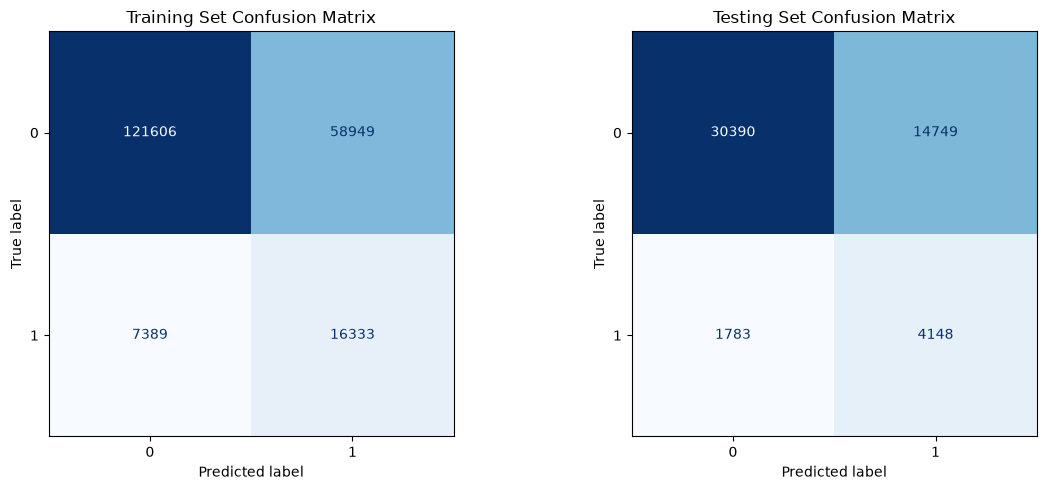

In [4]:
from matplotlib.ticker import StrMethodFormatter
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training Set
disp_train = ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_train_pred,
    display_labels=["Non-Default", "Default"],
    cmap="Blues",
    colorbar=False,
    values_format='d',
    ax=axes[0]
)
axes[0].set_title("Training Set Confusion Matrix")

# Testing Set
disp_test = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Non-Default", "Default"],
    cmap="Blues",
    colorbar=False,
    values_format='d',
    ax=axes[1]
)
axes[1].set_title("Testing Set Confusion Matrix")

# Prevent scientific notation on axes
for ax in axes:
    ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.0f}'))
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.0f}'))

plt.tight_layout()
plt.show()

### Interpretation

- **The training and testing confusion matrices exhibit very similar prediction patterns**, indicating that the Logistic Regression model generalizes well to unseen data without noticeable overfitting.

- The model correctly identifies **most non-default borrowers (True Negatives)** while also detecting a large proportion of **default borrowers (True Positives)**.

- A relatively **small number of default borrowers are misclassified as non-default (False Negatives)**, resulting in a **high Recall (~70%)**.

- However, the model generates a **considerable number of False Positives**, classifying some non-default borrowers as defaulters. This explains the **lower Precision (~22%)** observed earlier.

- **Overall, the model prioritizes identifying potential defaulters over minimizing false alarms.** Such a trade-off can be appropriate in loan default prediction, where failing to detect a true defaulter may be more costly than incorrectly flagging a non-defaulter.

### Receiver Operating Characteristic (ROC) Curve

The Receiver Operating Characteristic (ROC) curve evaluates the model's ability to distinguish between the **Default** and **Non-Default** classes across all possible classification thresholds.

The **Area Under the ROC Curve (ROC-AUC)** summarizes this performance into a single value ranging from **0.5** (random guessing) to **1.0** (perfect discrimination).

ROC curves for both the training and testing datasets are presented to compare the model's discriminative performance and assess its ability to generalize to unseen data.

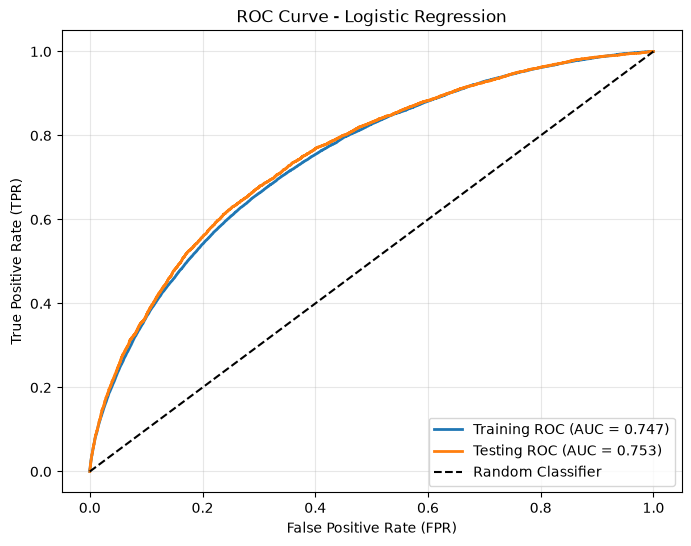

In [5]:


# ROC curve coordinates
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

# AUC scores
auc_train = roc_auc_score(y_train, y_train_prob)
auc_test = roc_auc_score(y_test, y_test_prob)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_train,
    tpr_train,
    linewidth=2,
    label=f"Training ROC (AUC = {auc_train:.3f})"
)

plt.plot(
    fpr_test,
    tpr_test,
    linewidth=2,
    label=f"Testing ROC (AUC = {auc_test:.3f})"
)

# Random classifier
plt.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Random Classifier")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

- **The ROC curves for the training and testing datasets almost completely overlap**, indicating that the Logistic Regression model generalizes well and does not exhibit noticeable overfitting.

- The model achieves an **ROC-AUC of 0.747 on the training set** and **0.753 on the testing set**, demonstrating a **moderate ability to distinguish** between default and non-default borrowers.

- Both curves lie **well above the diagonal reference line**, confirming that the model performs substantially better than random guessing.

- **Overall, the similar ROC-AUC values across both datasets suggest that the model has learned meaningful patterns that generalize effectively to unseen data.**

### Precision–Recall Curve

While the ROC curve evaluates the model's overall discriminative ability, the **Precision–Recall (PR) curve** focuses specifically on the performance of the **positive (Default)** class.

This curve illustrates the trade-off between **Precision** and **Recall** across different classification thresholds. It is particularly useful for **imbalanced datasets**, where correctly identifying the minority class is often more important than overall accuracy.

The **Average Precision (AP)** score summarizes the Precision–Recall curve into a single value, with higher values indicating better performance.

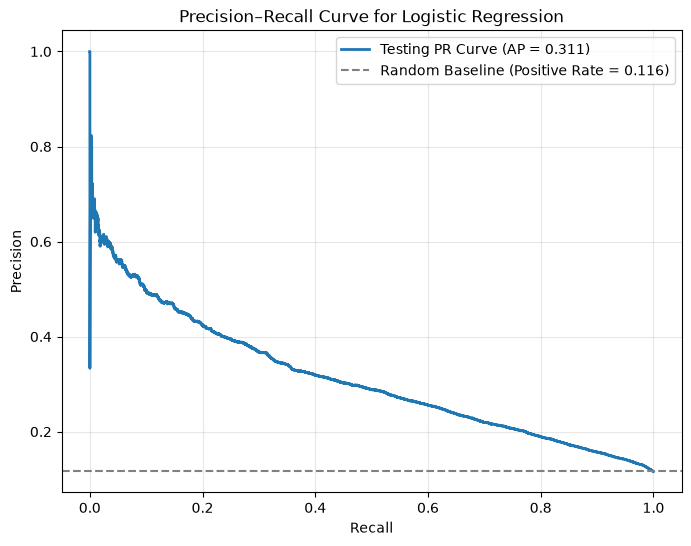

In [6]:
precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
ap = average_precision_score(y_test, y_test_prob)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"Testing PR Curve (AP = {ap:.3f})"
)

baseline = y_test.mean()

plt.axhline(
    baseline,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label=f"Random Baseline (Positive Rate = {baseline:.3f})"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve for Logistic Regression")

plt.grid(alpha=0.3)
plt.legend(loc="upper right")
plt.show()

### Interpretation

- **The Precision–Recall curve remains consistently above the baseline positive rate**, indicating that the Logistic Regression model performs substantially better than a naive classifier that predicts positives according to the class distribution.

- The model achieves an **Average Precision (AP) score of 0.311**, which is considerably higher than the baseline positive rate (**0.116**). This demonstrates meaningful predictive performance for the minority **Default** class.

- As expected, **precision decreases as recall increases**, illustrating the trade-off between identifying more default borrowers and reducing false positive predictions.

- **Overall, the Precision–Recall curve confirms that the model can effectively identify default cases despite the class imbalance**, making Logistic Regression a strong baseline model for this prediction task.

# Hyperparameter Tuning

The baseline Logistic Regression model was trained using Scikit-learn's default hyperparameters. Although these default settings often provide satisfactory performance, they are not guaranteed to be optimal for every dataset. Therefore, **hyperparameter tuning** is performed to identify the combination of hyperparameters that maximizes the model's predictive performance while maintaining good generalization.

Unlike **model parameters** (the regression coefficients), which are estimated from the training data during model fitting, **hyperparameters** are specified before training and govern how the learning algorithm fits the model.

---

## Hyperparameters Tuned

The following Logistic Regression hyperparameters are optimized.

### 1. Regularization Strength (`C`)

Logistic Regression with L2 regularization minimizes the following objective function:

$$
J(\boldsymbol{\beta})
=
-\ell(\boldsymbol{\beta})
+
\lambda
\sum_{j=1}^{p}\beta_j^2
$$

where:

- $\ell(\boldsymbol{\beta})$ is the log-likelihood.
- $\lambda$ is the regularization parameter.
- $\beta_j$ are the regression coefficients.

Rather than specifying the regularization parameter $\lambda$ directly, **Scikit-learn uses its reciprocal**:

$$
C=\frac{1}{\lambda}.
$$

Consequently:

- **Small values of $C$** correspond to **large values of $\lambda$**, resulting in **stronger regularization**.
- **Large values of $C$** correspond to **small values of $\lambda$**, resulting in **weaker regularization**.

During hyperparameter tuning, `GridSearchCV` evaluates multiple candidate values of **`C`**. Once the optimal value of `C` is selected, the corresponding regularization parameter is implicitly determined through

$$
\lambda=\frac{1}{C}.
$$

---

### 2. Optimization Solver (`solver`)

The solver specifies the numerical optimization algorithm used to minimize the regularized logistic loss function.

Different optimization algorithms may differ in convergence speed, numerical stability, and compatibility with different regularization penalties. Hyperparameter tuning evaluates multiple candidate solvers and selects the one that produces the best cross-validation performance.

---

## Grid Search

Hyperparameter optimization is performed using **Grid Search**, an exhaustive search strategy that evaluates every possible combination of predefined hyperparameter values.

If:

- $m$ candidate values of `C`, and
- $n$ candidate optimization solvers

are specified, then Grid Search evaluates

$$
m \times n
$$

different Logistic Regression models.

Each candidate model is independently trained and evaluated using cross-validation before the best-performing hyperparameter combination is selected.

---

## Stratified k-Fold Cross-Validation

Each hyperparameter combination is evaluated using **Stratified k-Fold Cross-Validation**.

The training dataset is partitioned into **$k$** approximately equal-sized folds while preserving the class distribution within every fold.

For each hyperparameter combination:

1. One fold is used as the validation set.
2. The remaining **$k-1$** folds are used for model training.
3. The validation score is recorded.
4. The process is repeated until every fold has served once as the validation set.

The average validation score is computed as

$$
\bar{S}
=
\frac{1}{k}
\sum_{i=1}^{k}
S_i
$$

where:

- $S_i$ denotes the validation score obtained from the $i^{\text{th}}$ fold.
- $k$ denotes the number of cross-validation folds.

The hyperparameter combination with the highest mean validation score is selected as the optimal model.

---

## Performance Metric

Since the loan default dataset is **imbalanced**, **ROC-AUC** is used as the optimization metric during hyperparameter tuning.

Unlike accuracy, ROC-AUC evaluates the model's ability to distinguish between default and non-default borrowers across all possible classification thresholds, making it a more appropriate criterion for selecting the optimal Logistic Regression model.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Define parameter grid
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "newton-cg", "saga"]
}

# Stratified 5-Fold Cross-Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Base Logistic Regression model
lr = LogisticRegression(
    penalty="l2",
    class_weight="balanced",
    max_iter=1000,          # Fixed convergence budget
    random_state=42
)

# Grid Search
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Perform hyperparameter tuning
grid_search.fit(X_train, y_train)

# Best model
best_lr = grid_search.best_estimator_

print("=" * 60)
print("Best Hyperparameters")
print("=" * 60)
print(grid_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:",
      f"{grid_search.best_score_:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Hyperparameters
{'C': 0.01, 'solver': 'saga'}

Best Cross-Validation ROC-AUC: 0.7464


### Interpretation

- To identify the most suitable Logistic Regression model, **Grid Search** evaluated **36 different hyperparameter combinations** using **5-fold Stratified Cross-Validation**, resulting in a total of **180 model fits**. Rather than relying on a single train-validation split, each candidate model was evaluated multiple times on different subsets of the training data to obtain a more reliable estimate of its performance.

- The optimal model was obtained with **C = 0.01** and **solver = "saga"**. These hyperparameters produced the highest average validation performance among all candidate models considered during the search.

- The selected value of **C = 0.01** corresponds to a relatively **strong level of L2 regularization**. In practical terms, this means the model preferred **simpler coefficient estimates** rather than fitting the training data too closely. Stronger regularization often improves the model's ability to generalize to unseen data by reducing the risk of overfitting.

- Among the optimization algorithms evaluated, **`saga`** achieved the best overall cross-validation performance. Additionally, **500 iterations** were sufficient for the optimization algorithm to converge, indicating that increasing the maximum number of iterations did not provide any further improvement.

- The optimal hyperparameter combination achieved a **mean cross-validation ROC-AUC of 0.7464**. This score represents the model's **average discriminative performance across the five validation folds**, rather than its performance on the independent testing dataset.

- **Overall, the hyperparameter tuning process identified the Logistic Regression configuration that is expected to provide the best balance between predictive performance and generalization.** The tuned model is therefore selected as the **final Logistic Regression model** for subsequent evaluation and interpretation.

In [8]:
# Predictions
y_train_pred_tuned = best_lr.predict(X_train)
y_test_pred_tuned = best_lr.predict(X_test)

# Predicted probabilities
y_train_prob_tuned = best_lr.predict_proba(X_train)[:, 1]
y_test_prob_tuned = best_lr.predict_proba(X_test)[:, 1]

# Performance metrics
tuned_performance = pd.DataFrame({
    "Accuracy": [
        accuracy_score(y_train, y_train_pred_tuned),
        accuracy_score(y_test, y_test_pred_tuned)
    ],
    "Precision": [
        precision_score(y_train, y_train_pred_tuned),
        precision_score(y_test, y_test_pred_tuned)
    ],
    "Recall": [
        recall_score(y_train, y_train_pred_tuned),
        recall_score(y_test, y_test_pred_tuned)
    ],
    "F1-Score": [
        f1_score(y_train, y_train_pred_tuned),
        f1_score(y_test, y_test_pred_tuned)
    ],
    "ROC-AUC": [
        roc_auc_score(y_train, y_train_prob_tuned),
        roc_auc_score(y_test, y_test_prob_tuned)
    ]
},
index=["Training Set", "Testing Set"])

tuned_performance = tuned_performance.round(4)

print("Tuned Logistic Regression Performance")
display(tuned_performance)

Tuned Logistic Regression Performance


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Training Set,0.6752,0.2170,0.6886,0.3300,0.7467
Testing Set,0.6766,0.2198,0.7001,0.3346,0.7532


In [9]:
# Baseline performance
baseline_performance = performance_df.copy()

# Tuned performance
tuned_performance_df = tuned_performance.copy()

# Add model labels
baseline_performance["Model"] = "Baseline"
tuned_performance_df["Model"] = "Tuned"

baseline_performance["Dataset"] = baseline_performance.index
tuned_performance_df["Dataset"] = tuned_performance_df.index

# Combine both tables
comparison_df = pd.concat(
    [baseline_performance, tuned_performance_df],
    ignore_index=True
)

# Reorder columns
comparison_df = comparison_df[
    [
        "Model",
        "Dataset",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]

display(comparison_df)

,Model,Dataset,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline,Training Set,0.6753,0.2170,0.6885,0.3299,0.7467
1,Baseline,Testing Set,0.6763,0.2195,0.6994,0.3341,0.7532
2,Tuned,Training Set,0.6752,0.2170,0.6886,0.3300,0.7467
3,Tuned,Testing Set,0.6766,0.2198,0.7001,0.3346,0.7532


### Interpretation

- The performance comparison indicates that the **baseline** and **tuned** Logistic Regression models exhibit **very similar predictive performance** across both the training and testing datasets.

- Hyperparameter tuning resulted in **small improvements** in the testing **Accuracy, Precision, Recall, and F1-score**, while the **ROC-AUC remained essentially unchanged**. This suggests that the baseline model was already close to the optimal solution for this dataset.

- The close agreement between the training and testing metrics for both models indicates **good generalization** and provides no evidence of substantial overfitting after hyperparameter tuning.

- Although the numerical improvements are modest, the tuned model was obtained through a **systematic optimization process using Grid Search with Stratified Cross-Validation**. Therefore, it represents the most robust and well-validated Logistic Regression model identified during this study.

- **Based on these results, the tuned Logistic Regression model is selected as the final model for subsequent interpretation and feature analysis.**

In [10]:
# Create coefficient table for the final tuned model
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": best_lr.coef_[0]
})

# Direction of effect
coef_df["Direction"] = coef_df["Coefficient"].apply(
    lambda x: "Positive" if x > 0 else "Negative"
)

# Absolute coefficient magnitude
coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()

# Sort by importance
coef_df = coef_df.sort_values(
    by="Absolute Coefficient",
    ascending=False
).reset_index(drop=True)

# Round values
coef_df["Coefficient"] = coef_df["Coefficient"].round(4)
coef_df["Absolute Coefficient"] = coef_df["Absolute Coefficient"].round(4)

display(coef_df)

,Feature,Coefficient,Direction,Absolute Coefficient
0,Age,-0.5809,Negative,0.5809
1,InterestRate,0.4570,Positive,0.4570
2,EmploymentType_Unemployed,0.4253,Positive,0.4253
3,MonthsEmployed,-0.3361,Negative,0.3361
4,Income,-0.3128,Negative,0.3128
5,LoanAmount,0.2867,Positive,0.2867
6,EmploymentType_Part-time,0.2572,Positive,0.2572
7,HasCoSigner,-0.2556,Negative,0.2556
8,HasDependents,-0.2493,Negative,0.2493
9,EmploymentType_Self-employed,0.2357,Positive,0.2357


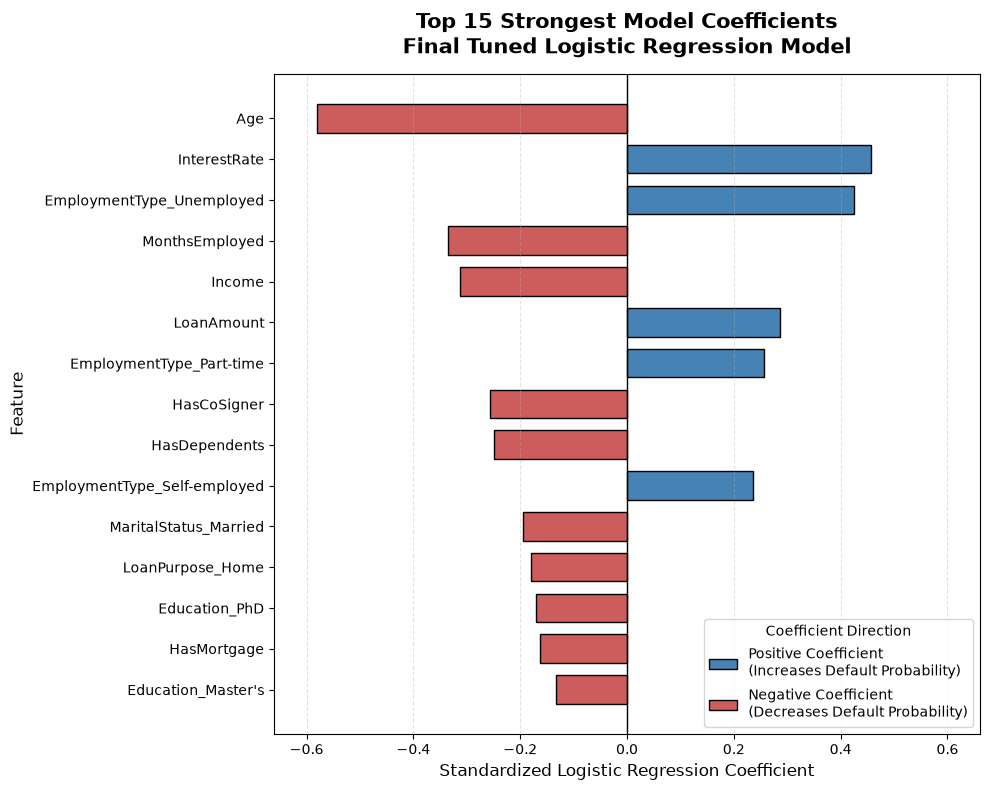

In [11]:
from matplotlib.patches import Patch

# Create dataframe
coef_plot_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": best_lr.coef_[0]
})

# Absolute coefficient for ranking
coef_plot_df["Absolute"] = coef_plot_df["Coefficient"].abs()

# Keep Top 15 most influential features
coef_plot_df = (
    coef_plot_df
    .sort_values("Absolute", ascending=False)
    .head(15)
)

# Colors based on coefficient direction
colors = [
    "steelblue" if coef > 0 else "indianred"
    for coef in coef_plot_df["Coefficient"]
]

# Plot
plt.figure(figsize=(10, 8))

plt.barh(
    coef_plot_df["Feature"],
    coef_plot_df["Coefficient"],
    color=colors,
    edgecolor="black",
    height=0.7
)

# Highest importance on top
plt.gca().invert_yaxis()

# Zero reference line
plt.axvline(0, color="black", linewidth=1)

# Symmetric x-axis
max_coef = coef_plot_df["Absolute"].max()
plt.xlim(-max_coef - 0.08, max_coef + 0.08)

plt.title(
    "Top 15 Strongest Model Coefficients\nFinal Tuned Logistic Regression Model",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Standardized Logistic Regression Coefficient", fontsize=12)
plt.ylabel("Feature", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.35)


legend_elements = [
    Patch(facecolor="steelblue", edgecolor="black",
          label="Positive Coefficient\n(Increases Default Probability)"),
    Patch(facecolor="indianred", edgecolor="black",
          label="Negative Coefficient\n(Decreases Default Probability)")
]

plt.legend(
    handles=legend_elements,
    loc="lower right",
    frameon=True,
    fontsize=10,
    title="Coefficient Direction"
)

plt.tight_layout()
plt.show()

### Interpretation

- The table and figure summarize the **final tuned Logistic Regression model**, with predictors ranked according to the **absolute magnitude of their standardized coefficients**. Larger absolute coefficients indicate a greater influence on the model's prediction, while the sign of the coefficient indicates the direction of the relationship with loan default.

- **Age** is the most influential predictor in the model and has a **negative coefficient**, indicating that higher age is associated with a lower predicted probability of loan default, after accounting for the other variables in the model.

- **Interest Rate** and **Unemployment Status** are the two most influential **positive predictors**, indicating that higher interest rates and being unemployed are associated with an increased predicted probability of loan default.

- Other influential predictors include **Months Employed**, **Income**, **Loan Amount**, **Employment Type**, **Has Co-signer**, and **Has Dependents**, suggesting that both financial characteristics and borrower demographics contribute meaningfully to the model's predictions.

- The coefficient plot provides a visual ranking of the **15 most influential predictors**. **Blue bars** represent variables that increase the predicted probability of loan default, whereas **red bars** represent variables that decrease the predicted probability of loan default. The longer the bar, the greater the feature's relative influence on the model prediction.

- Since the numerical predictors were standardized before model training, the coefficient magnitudes are directly comparable. However, these coefficients should be interpreted as **relative model influence rather than causal effects**, as Logistic Regression identifies statistical associations within the observed data rather than cause-and-effect relationships.

## Odds Ratio Interpretation

While Logistic Regression coefficients indicate the **direction** and **relative influence** of each predictor, they are expressed on the **log-odds scale**, which is often difficult to interpret directly.

To improve interpretability, the coefficients are transformed into **Odds Ratios (OR)** using

$$
\text{Odds Ratio}=e^{\beta},
$$

where $\beta$ denotes the Logistic Regression coefficient.

The Odds Ratio represents the multiplicative change in the **odds of loan default** associated with a **one-unit increase in the standardized predictor**, while holding all other predictors constant.

The interpretation is straightforward:

- **Odds Ratio > 1:** The predictor is associated with **higher odds of loan default**.
- **Odds Ratio < 1:** The predictor is associated with **lower odds of loan default**.
- **Odds Ratio = 1:** The predictor has **no association** with the odds of loan default.

In [12]:
# Odds Ratio table for the final tuned model
odds_ratio_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": best_lr.coef_[0]
})

# Calculate Odds Ratios
odds_ratio_df["Odds Ratio"] = np.exp(odds_ratio_df["Coefficient"])

# Effect direction
odds_ratio_df["Effect"] = odds_ratio_df["Odds Ratio"].apply(
    lambda x: "Increase in Default Odds" if x > 1 else "Decrease in Default Odds"
)

# Sort by absolute coefficient magnitude
odds_ratio_df["Absolute Coefficient"] = odds_ratio_df["Coefficient"].abs()

odds_ratio_df = (
    odds_ratio_df
    .sort_values("Absolute Coefficient", ascending=False)
    .drop(columns="Absolute Coefficient")
    .reset_index(drop=True)
)

# Round values
odds_ratio_df["Coefficient"] = odds_ratio_df["Coefficient"].round(4)
odds_ratio_df["Odds Ratio"] = odds_ratio_df["Odds Ratio"].round(3)

display(odds_ratio_df)

,Feature,Coefficient,Odds Ratio,Effect
0,Age,-0.5809,0.559,Decrease in Default Odds
1,InterestRate,0.4570,1.579,Increase in Default Odds
2,EmploymentType_Unemployed,0.4253,1.530,Increase in Default Odds
3,MonthsEmployed,-0.3361,0.715,Decrease in Default Odds
4,Income,-0.3128,0.731,Decrease in Default Odds
5,LoanAmount,0.2867,1.332,Increase in Default Odds
6,EmploymentType_Part-time,0.2572,1.293,Increase in Default Odds
7,HasCoSigner,-0.2556,0.774,Decrease in Default Odds
8,HasDependents,-0.2493,0.779,Decrease in Default Odds
9,EmploymentType_Self-employed,0.2357,1.266,Increase in Default Odds


## Logistic Regression: Summary and Key Findings

- Logistic Regression achieved **consistent performance** on both the training and testing datasets, indicating **good generalization** with no evidence of substantial overfitting.

- Hyperparameter tuning using **Grid Search with 5-fold Stratified Cross-Validation** produced only **marginal improvements** over the baseline model. This suggests that the default Logistic Regression model was already close to the optimal solution for the given dataset.

- The tuned model achieved a **testing ROC-AUC of approximately 0.75**, demonstrating a reasonable ability to distinguish between borrowers who default and those who do not.

- The coefficient and odds ratio analyses identified **Age**, **Interest Rate**, **Employment Status**, **Months Employed**, **Income**, and **Loan Amount** as the most influential predictors of loan default.

- One of the major advantages of Logistic Regression is its **high interpretability**. The model provides coefficients and odds ratios that clearly explain how each predictor influences the probability of loan default, making it particularly suitable for financial and credit-risk applications where model transparency is important.

- However, Logistic Regression assumes a **linear relationship between the predictors and the log-odds of the target variable**. As a result, it may not fully capture complex nonlinear relationships and interactions that can exist within real-world financial data.

- Overall, Logistic Regression provides a **strong and interpretable baseline model** for loan default prediction and serves as an effective benchmark against which more complex machine learning models, such as Random Forest and XGBoost, can be compared.

# Random Forest Classifier

Random Forest is a **supervised ensemble learning algorithm** that constructs a large collection of decision trees and combines their predictions to perform classification or regression tasks. Unlike Logistic Regression, which assumes a linear relationship between the predictors and the log-odds of the response, Random Forest is a **non-parametric model** capable of capturing complex nonlinear relationships and interactions among predictors.

## Working Principle

A Random Forest consists of many decision trees trained on different random subsets of the training data. Each tree independently predicts the target class, and the final prediction is obtained by **majority voting**.

The algorithm relies on two key sources of randomness:

1. **Bootstrap Sampling (Bagging)**
   - For each decision tree, a bootstrap sample is generated by randomly sampling observations **with replacement** from the original training dataset.
   - Because each tree is trained on a different sample, the trees become diverse and less correlated.

2. **Random Feature Selection**
   - At every split within a tree, only a random subset of predictors is considered instead of evaluating all available features.
   - This additional randomness further reduces the correlation between trees and improves the robustness of the ensemble.

## Mathematical Formulation

Suppose a Random Forest contains $B$ decision trees,

$$
\{T_1, T_2, \ldots, T_B\}.
$$

For an observation $x$, each tree predicts a class

$$
T_b(x), \qquad b = 1,2,\ldots,B.
$$

The Random Forest classifier assigns the class receiving the largest number of votes,

$$
\hat{y}
=
\operatorname{mode}
\left\{
T_1(x),
T_2(x),
\ldots,
T_B(x)
\right\}.
$$

Thus, instead of relying on a single decision tree, the model combines the predictions of many independently trained trees to produce a more stable and accurate prediction.

## Reduction in Variance

If the individual trees have variance

$$
\operatorname{Var}(T),
$$

and pairwise correlation

$$
\rho,
$$

then the variance of the Random Forest ensemble can be approximated as

$$
\operatorname{Var}(\text{RF})
=
\rho\,\operatorname{Var}(T)
+
\frac{1-\rho}{B}\operatorname{Var}(T),
$$

where

- $B$ = number of decision trees
- $\rho$ = average correlation between trees

As the number of trees increases and the correlation between trees decreases, the overall variance of the ensemble is substantially reduced, leading to improved generalization performance.

## Important Hyperparameters

The primary hyperparameters controlling the Random Forest model include:

- **`n_estimators`** – Number of decision trees in the forest.
- **`max_depth`** – Maximum depth allowed for each tree.
- **`min_samples_split`** – Minimum number of samples required to split an internal node.
- **`min_samples_leaf`** – Minimum number of observations required in each terminal node.
- **`max_features`** – Number of predictors randomly considered at each split.
- **`class_weight`** – Adjusts for class imbalance by assigning higher weights to the minority class.

These hyperparameters influence the balance between model complexity, predictive performance, and generalization.

## Implementation in Scikit-learn

In this study, the Random Forest model is implemented using **`RandomForestClassifier`** from the **Scikit-learn** library.

The implementation uses the **Classification and Regression Trees (CART)** algorithm to construct each decision tree within the forest.

For classification problems, the CART algorithm recursively partitions the feature space by selecting the split that maximizes the reduction in node impurity. By default, Scikit-learn measures node impurity using the **Gini Impurity** criterion,

$$
G
=
1-
\sum_{i=1}^{K}
p_i^2,
$$

where

- $K$ denotes the number of classes.
- $p_i$ is the proportion of observations belonging to class $i$ within a node.

At each split, the algorithm selects the feature and threshold that produce the greatest decrease in Gini Impurity. This recursive partitioning continues until a stopping criterion, such as the maximum tree depth or minimum number of samples required for a split, is reached.

Each decision tree is trained on a bootstrap sample of the training data, and only a random subset of predictors is considered when evaluating each candidate split. These two sources of randomness reduce the correlation among individual trees and improve the overall robustness of the ensemble.

The final prediction for a new observation is obtained through **majority voting**, where each tree independently predicts a class and the class receiving the largest number of votes is returned as the final prediction.

## Advantages

- Captures nonlinear relationships and complex feature interactions.
- Naturally handles both numerical and categorical predictors after preprocessing.
- Less prone to overfitting than a single decision tree due to ensemble averaging.
- Provides estimates of feature importance.
- Generally achieves strong predictive performance with relatively little parameter tuning.

## Limitations

- Less interpretable than Logistic Regression because predictions are generated from many decision trees.
- Computationally more expensive to train and evaluate.
- Does not provide directly interpretable coefficients or odds ratios.
- Feature importance measures indicate relative contribution but should not be interpreted as causal effects.

## Application in This Study

In this study, the Random Forest classifier is trained to predict **loan default**. Its performance will be compared with Logistic Regression and XGBoost to evaluate whether a nonlinear ensemble method provides improved predictive accuracy while maintaining good generalization to unseen data.

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the baseline Random Forest model
rf_model = RandomForestClassifier(
    criterion="gini",
    bootstrap=True,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Baseline Random Forest model trained successfully.")

Baseline Random Forest model trained successfully.


In [14]:
# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Predicted probabilities
y_train_prob_rf = rf_model.predict_proba(X_train)[:, 1]
y_test_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Performance metrics
rf_performance = pd.DataFrame({
    "Accuracy": [
        accuracy_score(y_train, y_train_pred_rf),
        accuracy_score(y_test, y_test_pred_rf)
    ],
    "Precision": [
        precision_score(y_train, y_train_pred_rf),
        precision_score(y_test, y_test_pred_rf)
    ],
    "Recall": [
        recall_score(y_train, y_train_pred_rf),
        recall_score(y_test, y_test_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_train, y_train_pred_rf),
        f1_score(y_test, y_test_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_train, y_train_prob_rf),
        roc_auc_score(y_test, y_test_prob_rf)
    ]
},
index=["Training Set", "Testing Set"])

rf_performance = rf_performance.round(4)

print("Baseline Random Forest Performance")
display(rf_performance)

Baseline Random Forest Performance


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Training Set,1.0000,0.9997,1.0000,0.9999,1.0000
Testing Set,0.8794,0.4457,0.1585,0.2338,0.7411


### Interpretation

- The baseline Random Forest model achieves **perfect performance on the training dataset** (Accuracy = 1.0000, ROC-AUC = 1.0000), indicating that it has learned the training data almost exactly.

- However, the testing performance is **considerably lower**, with a **ROC-AUC of 0.7411**, indicating that the model does not generalize to unseen data as effectively as it performs on the training data.

- A substantial gap between the training and testing metrics is a strong indication of **overfitting**. The baseline Random Forest has likely become too complex, capturing patterns specific to the training data rather than general relationships that extend to new observations.

- The testing **Precision (0.4457)** is higher than that of Logistic Regression, meaning that a larger proportion of predicted defaults are correct. However, the **Recall (0.1585)** is substantially lower, indicating that the model fails to identify a large proportion of actual loan defaults.

- These results suggest that, although the baseline Random Forest is highly expressive, its default hyperparameters do not provide an appropriate balance between model complexity and generalization for this dataset.

- **Therefore, hyperparameter tuning is required to reduce overfitting, improve generalization, and achieve a better trade-off between Precision and Recall.**

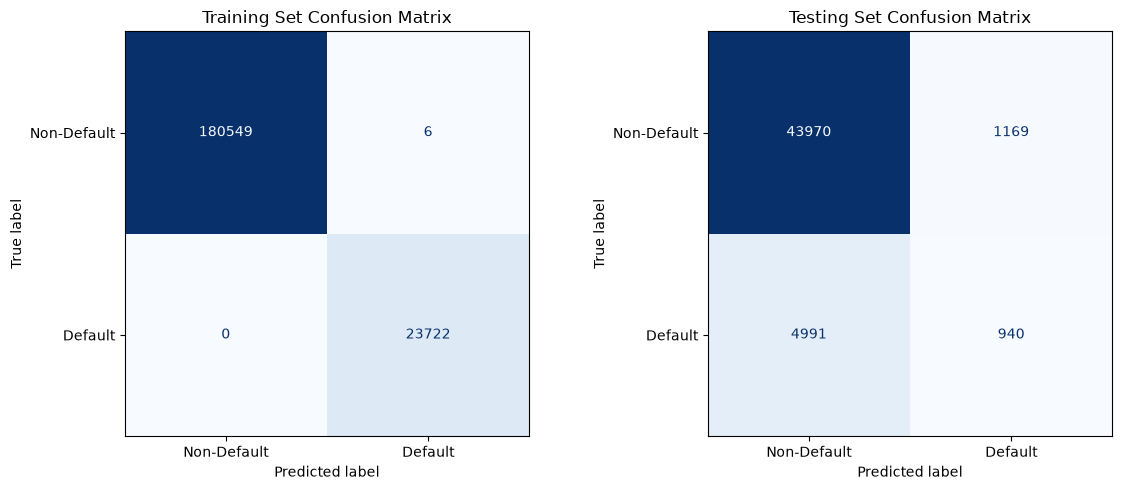

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_train_pred_rf,
    display_labels=["Non-Default", "Default"],
    cmap="Blues",
    colorbar=False,
    values_format="d",
    ax=axes[0]
)

axes[0].set_title("Training Set Confusion Matrix")

# Testing confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_rf,
    display_labels=["Non-Default", "Default"],
    cmap="Blues",
    colorbar=False,
    values_format="d",
    ax=axes[1]
)

axes[1].set_title("Testing Set Confusion Matrix")

plt.tight_layout()
plt.show()

### Interpretation

- The **training confusion matrix** shows that the Random Forest model classifies almost every training observation correctly, indicating an **almost perfect fit** to the training data.

- In contrast, the **testing confusion matrix** contains a large number of **False Negatives**, meaning that many actual loan defaults are incorrectly classified as non-defaults. This explains the model's **low Recall** observed during performance evaluation.

- The substantial difference between the training and testing confusion matrices provides strong evidence of **overfitting**, where the baseline Random Forest has learned the training data too closely but does not generalize equally well to unseen observations.

- **Hyperparameter tuning is therefore required** to reduce model complexity, improve generalization, and achieve a better balance between identifying default and non-default borrowers.

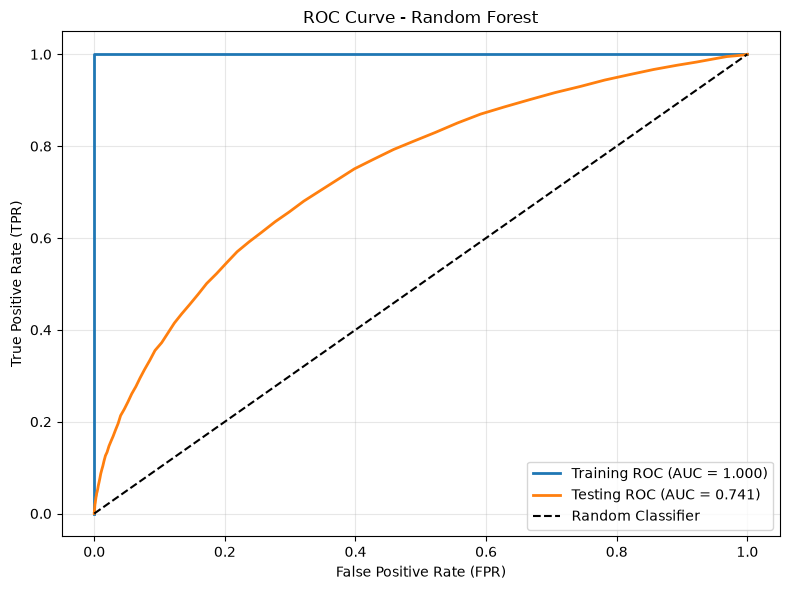

In [16]:
# ROC curve values
fpr_train_rf, tpr_train_rf, _ = roc_curve(y_train, y_train_prob_rf)
fpr_test_rf, tpr_test_rf, _ = roc_curve(y_test, y_test_prob_rf)

# ROC-AUC scores
train_auc_rf = roc_auc_score(y_train, y_train_prob_rf)
test_auc_rf = roc_auc_score(y_test, y_test_prob_rf)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_train_rf,
    tpr_train_rf,
    linewidth=2,
    label=f"Training ROC (AUC = {train_auc_rf:.3f})"
)

plt.plot(
    fpr_test_rf,
    tpr_test_rf,
    linewidth=2,
    label=f"Testing ROC (AUC = {test_auc_rf:.3f})"
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - Random Forest")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

- The **training ROC curve** achieves a **perfect ROC-AUC of 1.000**, whereas the **testing ROC curve** achieves a **ROC-AUC of 0.741**, indicating a noticeable decline in performance on unseen data.

- The large gap between the training and testing ROC curves provides further evidence of **overfitting**, suggesting that the baseline Random Forest has memorized the training data rather than learned patterns that generalize well.

- Nevertheless, the testing ROC curve remains well above the random classifier, indicating that the model still possesses reasonable discriminatory ability. 

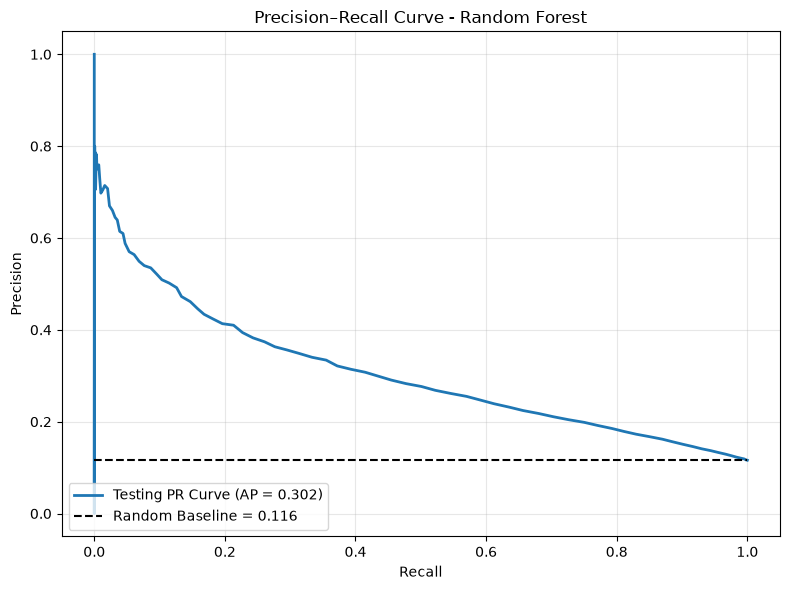

In [17]:
# Precision-Recall values
precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    y_test_prob_rf
)

# Average Precision
ap_rf = average_precision_score(
    y_test,
    y_test_prob_rf
)

# Baseline (positive class prevalence)
baseline = y_test.mean()

plt.figure(figsize=(8,6))

plt.plot(
    recall_rf,
    precision_rf,
    linewidth=2,
    label=f"Testing PR Curve (AP = {ap_rf:.3f})"
)

plt.hlines(
    baseline,
    xmin=0,
    xmax=1,
    colors="black",
    linestyles="--",
    label=f"Random Baseline = {baseline:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - Random Forest")

plt.grid(alpha=0.3)
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

### Interpretation

- The testing **Precision–Recall curve** lies well above the random baseline, indicating that the Random Forest model identifies loan defaults substantially better than random guessing.

- The **Average Precision (AP = 0.302)** is considerably higher than the baseline default rate (**0.116**), demonstrating that the model has meaningful predictive ability for the minority (default) class.

- However, Precision decreases as Recall increases, illustrating the inherent trade-off between correctly identifying more defaulters and reducing false positive predictions.

# Hyperparameter Tuning

The baseline Random Forest model exhibited **near-perfect performance on the training data but substantially lower performance on the testing data**, indicating that the model had **overfit** the training dataset.

To improve the model's generalization ability, **RandomizedSearchCV** is employed to search for a better combination of hyperparameters.

Unlike Grid Search, which evaluates every possible hyperparameter combination, **Randomized Search randomly samples a fixed number of candidate combinations from the predefined search space**. This approach is computationally more efficient for models such as Random Forest that contain numerous hyperparameters.

For each sampled combination, model performance is evaluated using **5-fold Stratified Cross-Validation**, ensuring that the class distribution is preserved in every fold.

The hyperparameter combination producing the highest mean **ROC-AUC** across the validation folds is selected as the final tuned model.

## Hyperparameters Considered

The following Random Forest hyperparameters are optimized:

- **n_estimators:** Number of decision trees in the forest.
- **max_depth:** Maximum depth allowed for each decision tree.
- **min_samples_split:** Minimum number of samples required to split an internal node.
- **min_samples_leaf:** Minimum number of samples required in a terminal node.
- **max_features:** Number of randomly selected features evaluated at each split.

The objective is to identify a model that achieves **strong predictive performance while reducing overfitting and improving generalization to unseen data.**

In [18]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint

# Parameter distributions
param_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": randint(2, 15),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2"]
}

# Stratified 5-Fold Cross-Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Base Random Forest
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=4
)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=4,
    verbose=1,
    return_train_score=True
)

# Fit search
random_search.fit(X_train, y_train)

# Best model
best_rf = random_search.best_estimator_

print("=" * 60)
print("Best Hyperparameters")
print("=" * 60)
print(random_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:",
      f"{random_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Hyperparameters
{'max_depth': 30, 'max_features': 'log2', 'min_samples_leaf': 9, 'min_samples_split': 4, 'n_estimators': 406}

Best Cross-Validation ROC-AUC: 0.7482


In [19]:
# Predictions using the tuned Random Forest model
y_train_pred_rf_tuned = best_rf.predict(X_train)
y_test_pred_rf_tuned = best_rf.predict(X_test)

# Prediction probabilities
y_train_prob_rf_tuned = best_rf.predict_proba(X_train)[:, 1]
y_test_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

# Performance metrics for the tuned model
rf_tuned_performance = pd.DataFrame({
    "Accuracy": [
        accuracy_score(y_train, y_train_pred_rf_tuned),
        accuracy_score(y_test, y_test_pred_rf_tuned)
    ],
    "Precision": [
        precision_score(y_train, y_train_pred_rf_tuned),
        precision_score(y_test, y_test_pred_rf_tuned)
    ],
    "Recall": [
        recall_score(y_train, y_train_pred_rf_tuned),
        recall_score(y_test, y_test_pred_rf_tuned)
    ],
    "F1-Score": [
        f1_score(y_train, y_train_pred_rf_tuned),
        f1_score(y_test, y_test_pred_rf_tuned)
    ],
    "ROC-AUC": [
        roc_auc_score(y_train, y_train_prob_rf_tuned),
        roc_auc_score(y_test, y_test_prob_rf_tuned)
    ]
},
index=["Training Set", "Testing Set"])

rf_tuned_performance = rf_tuned_performance.round(4)

# -----------------------------
# Compare Baseline vs Tuned Model
# -----------------------------

baseline_rf = rf_performance.copy()
baseline_rf["Model"] = "Baseline"

tuned_rf = rf_tuned_performance.copy()
tuned_rf["Model"] = "Tuned"

baseline_rf["Dataset"] = baseline_rf.index
tuned_rf["Dataset"] = tuned_rf.index

rf_comparison = pd.concat(
    [baseline_rf, tuned_rf],
    ignore_index=True
)

rf_comparison = rf_comparison[
    [
        "Model",
        "Dataset",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]

print("Baseline vs Tuned Random Forest Performance")
display(rf_comparison)

Baseline vs Tuned Random Forest Performance


,Model,Dataset,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline,Training Set,1.0000,0.9997,1.0000,0.9999,1.0000
1,Baseline,Testing Set,0.8794,0.4457,0.1585,0.2338,0.7411
2,Tuned,Training Set,0.8751,0.4814,0.9712,0.6437,0.9719
3,Tuned,Testing Set,0.7852,0.2786,0.5343,0.3662,0.7542


### Interpretation

- Hyperparameter tuning **successfully reduced overfitting**. The baseline model achieved perfect performance on the training data, whereas the tuned model exhibits a much smaller gap between the training and testing results.

- Compared with the baseline model, the tuned Random Forest achieved a **higher testing ROC-AUC (0.7542 vs. 0.7411)**, indicating improved discrimination between default and non-default borrowers.

- Although **Precision decreased (0.4457 → 0.2786)**, the tuned model achieved a substantial improvement in **Recall (0.1585 → 0.5343)** and **F1-score (0.2338 → 0.3662)**, demonstrating a better overall balance in identifying loan defaults.

- Overall, the tuned Random Forest provides **better generalization** and is selected as the final Random Forest model for subsequent feature importance analysis and comparison with the other machine learning models.

## Feature Importance

Unlike Logistic Regression, Random Forest does not estimate regression coefficients. Instead, it quantifies the **relative importance** of each predictor based on its total contribution to reducing node impurity across all decision trees in the forest.

The feature importance values are computed using the **Mean Decrease in Impurity (MDI)** criterion. During tree construction, each split reduces the Gini impurity of the data. The impurity reductions attributed to each feature are accumulated across all trees and then normalized so that the importance scores sum to 1.

Features with larger importance values contribute more to the model's predictions, whereas features with smaller values have relatively less influence. These scores represent **relative predictive importance** and **should not be interpreted as causal effects or as indicating the direction of the relationship**.

,Feature,Importance
0,Age,0.1848
1,InterestRate,0.1566
2,Income,0.1382
3,LoanAmount,0.1107
4,MonthsEmployed,0.1078
5,CreditScore,0.0775
6,DTIRatio,0.0660
7,NumCreditLines,0.0245
8,HasCoSigner,0.0127
9,HasDependents,0.0126


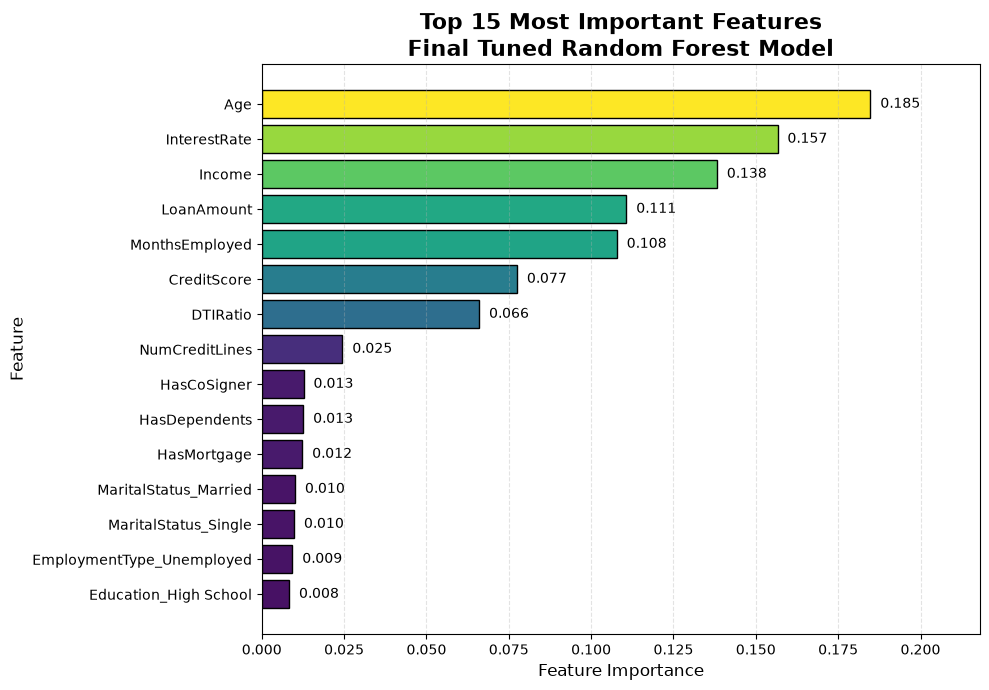

In [20]:
import matplotlib.pyplot as plt

# ==========================
# Feature Importance Table
# ==========================

feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df["Importance"] = feature_importance_df["Importance"].round(4)

display(feature_importance_df)

# ==========================
# Top 15 Feature Importance Plot
# ==========================

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1],
    color=plt.cm.viridis(
        top_features["Importance"][::-1] /
        top_features["Importance"].max()
    ),
    edgecolor="black"
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.003,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        fontsize=10
    )

plt.title(
    "Top 15 Most Important Features\nFinal Tuned Random Forest Model",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Feature Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)

# Leave space for labels
plt.xlim(0, top_features["Importance"].max() * 1.18)

plt.grid(axis="x", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

## Random Forest Summary

The baseline Random Forest model demonstrated **excellent performance on the training dataset** but exhibited clear signs of **overfitting**, with substantially lower performance on the testing dataset.

To improve generalization, **RandomizedSearchCV** with **5-fold Stratified Cross-Validation** was employed to optimize the model hyperparameters using **ROC-AUC** as the evaluation metric.

The optimal hyperparameter configuration obtained was:

- **Number of Trees (`n_estimators`) = 406**
- **Maximum Tree Depth (`max_depth`) = 30**
- **Maximum Features per Split (`max_features`) = `"log2"`**
- **Minimum Samples to Split (`min_samples_split`) = 4**
- **Minimum Samples per Leaf (`min_samples_leaf`) = 9**

Compared with the baseline model, the tuned Random Forest achieved:

- Reduced overfitting by narrowing the gap between the training and testing performance.
- Improved **testing ROC-AUC (0.7542)**, indicating better discrimination between default and non-default borrowers.
- A substantial improvement in **Recall** and **F1-score**, resulting in better identification of loan defaults on unseen data.
- A more balanced trade-off between predictive performance and model complexity.

Feature importance analysis further identified the variables that contributed most to the model's predictions. Based on these results, the **tuned Random Forest model** is selected as the final Random Forest classifier and will be included in the final comparison with Logistic Regression and XGBoost.

# XGBoost (Extreme Gradient Boosting)

XGBoost (Extreme Gradient Boosting) is an advanced **ensemble machine learning algorithm** based on the principle of **gradient boosting**. Unlike Random Forest, where decision trees are built **independently and in parallel**, XGBoost constructs trees **sequentially**, with each new tree attempting to correct the prediction errors made by the previous ensemble.

The XGBoost implementation used in this study is **`xgboost.XGBClassifier`**, which employs the **Gradient Boosted Decision Tree (GBDT)** algorithm for binary classification.

## Mathematical Formulation

For a dataset containing observations

$$
D=\{(x_i,y_i)\}_{i=1}^{n},
$$

the prediction after $t$ boosting iterations is

$$
\hat{y}_i^{(t)}
=
\sum_{k=1}^{t} f_k(x_i),
$$

where

- $f_k(x)$ denotes the $k^{\text{th}}$ decision tree.
- Each tree predicts the residual errors of the previous ensemble.

Unlike Random Forest, where every tree has equal importance, XGBoost **adds one tree at a time**, gradually improving the model.

## Objective Function

The model minimizes the following regularized objective function:

$$
\mathcal{L}
=
\sum_{i=1}^{n}
l(y_i,\hat{y}_i)
+
\sum_{k=1}^{K}
\Omega(f_k).
$$

where

- $l(y_i,\hat{y}_i)$ is the classification loss (log loss for binary classification).
- $\Omega(f_k)$ is a regularization term controlling model complexity.

The regularization term is

$$
\Omega(f)
=
\gamma T
+
\frac{\lambda}{2}
\sum_{j=1}^{T}w_j^2,
$$

where

- $T$ = number of terminal leaves.
- $w_j$ = weight assigned to the $j^{\text{th}}$ leaf.
- $\gamma$ penalizes overly complex trees.
- $\lambda$ provides L2 regularization on leaf weights.

Regularization helps reduce overfitting while improving generalization.

## Gradient Boosting

Instead of fitting every tree independently, XGBoost fits each new tree to the **gradient (first derivative)** of the loss function.

For binary classification using logistic loss,

$$
g_i
=
\frac{\partial l(y_i,\hat{y}_i)}
{\partial \hat{y}_i},
$$

and

$$
h_i
=
\frac{\partial^2 l(y_i,\hat{y}_i)}
{\partial \hat{y}_i^2},
$$

where

- $g_i$ is the first-order gradient.
- $h_i$ is the second-order Hessian.

Using both first- and second-order information allows XGBoost to optimize the objective more efficiently than traditional Gradient Boosting.

## Prediction Probability

For binary classification, the final prediction is transformed into a probability using the sigmoid function:

$$
P(Y=1\mid X)
=
\frac{1}{1+e^{-\hat{y}}}.
$$

where

$$
\hat{y}
=
\sum_{k=1}^{K}
f_k(x).
$$

A probability greater than the classification threshold (typically 0.5) is classified as **Loan Default**; otherwise, it is classified as **Non-Default**.

## Important Hyperparameters

Some of the most influential hyperparameters are:

- **`n_estimators`** – Number of boosting rounds (trees).
- **`learning_rate`** – Controls the contribution of each new tree.
- **`max_depth`** – Maximum depth of each decision tree.
- **`subsample`** – Fraction of training observations randomly sampled for each tree.
- **`colsample_bytree`** – Fraction of predictor variables randomly sampled for each tree.
- **`gamma`** – Minimum reduction in loss required before creating another split.
- **`min_child_weight`** – Minimum sum of observation weights required in a leaf node.
- **`reg_alpha`** – L1 regularization strength.
- **`reg_lambda`** – L2 regularization strength.

These parameters jointly determine the balance between predictive accuracy and overfitting.

## Advantages

- Captures highly complex nonlinear relationships.
- Learns feature interactions automatically.
- Includes built-in L1 and L2 regularization.
- Handles large structured datasets efficiently.
- Generally achieves state-of-the-art predictive performance for tabular data.
- Naturally provides feature importance measures.

## Limitations

- Computationally more expensive than Logistic Regression.
- Requires careful hyperparameter tuning.
- Less interpretable than Logistic Regression.
- Individual feature importance values indicate predictive contribution rather than causal relationships.

## Application in This Study

In this study, XGBoost is trained to predict **loan default** using the preprocessed borrower information. Its predictive performance will be evaluated using the same performance metrics as Logistic Regression and Random Forest. Hyperparameter tuning will then be performed to obtain the optimal model, and the final tuned XGBoost classifier will be compared against the other machine learning models to identify the best-performing approach for loan default prediction.

In [21]:
# Compute imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"scale_pos_weight = {scale_pos_weight:.2f}")

scale_pos_weight = 7.61


In [22]:
from xgboost import XGBClassifier

# Baseline XGBoost model
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

# Train the model
xgb_model.fit(X_train, y_train)

print("Baseline XGBoost model trained successfully.")

Baseline XGBoost model trained successfully.


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Prediction probabilities
y_train_prob_xgb = xgb_model.predict_proba(X_train)[:, 1]
y_test_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Performance metrics
xgb_performance = pd.DataFrame({
    "Accuracy": [
        accuracy_score(y_train, y_train_pred_xgb),
        accuracy_score(y_test, y_test_pred_xgb)
    ],
    "Precision": [
        precision_score(y_train, y_train_pred_xgb),
        precision_score(y_test, y_test_pred_xgb)
    ],
    "Recall": [
        recall_score(y_train, y_train_pred_xgb),
        recall_score(y_test, y_test_pred_xgb)
    ],
    "F1-Score": [
        f1_score(y_train, y_train_pred_xgb),
        f1_score(y_test, y_test_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_train, y_train_prob_xgb),
        roc_auc_score(y_test, y_test_prob_xgb)
    ]
},
index=["Training Set", "Testing Set"])

xgb_performance = xgb_performance.round(4)

print("Baseline XGBoost Performance")
display(xgb_performance)

Baseline XGBoost Performance


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Training Set,0.7487,0.2852,0.7724,0.4166,0.8415
Testing Set,0.7134,0.2295,0.6228,0.3354,0.7421


### Interpretation

- The baseline XGBoost classifier achieved a **testing ROC-AUC of 0.7421**, indicating good discrimination between default and non-default borrowers.

- The difference between the training and testing performance is moderate, suggesting that the baseline model generalizes reasonably well while still exhibiting some degree of overfitting.

- The model achieved a **Recall of 0.6228**, indicating that approximately **62.3%** of the actual loan defaults were correctly identified. However, this was accompanied by a relatively low **Precision (0.2295)**, meaning that a considerable proportion of borrowers predicted as defaults were actually non-default borrowers.

- The **F1-score of 0.3354** reflects the balance between Precision and Recall and provides an overall assessment of the classifier's effectiveness in identifying the minority (default) class.

- Although the baseline model demonstrates satisfactory predictive performance, further improvement may be achieved through **hyperparameter tuning**, which aims to reduce overfitting and optimize the model's ability to generalize to unseen data.

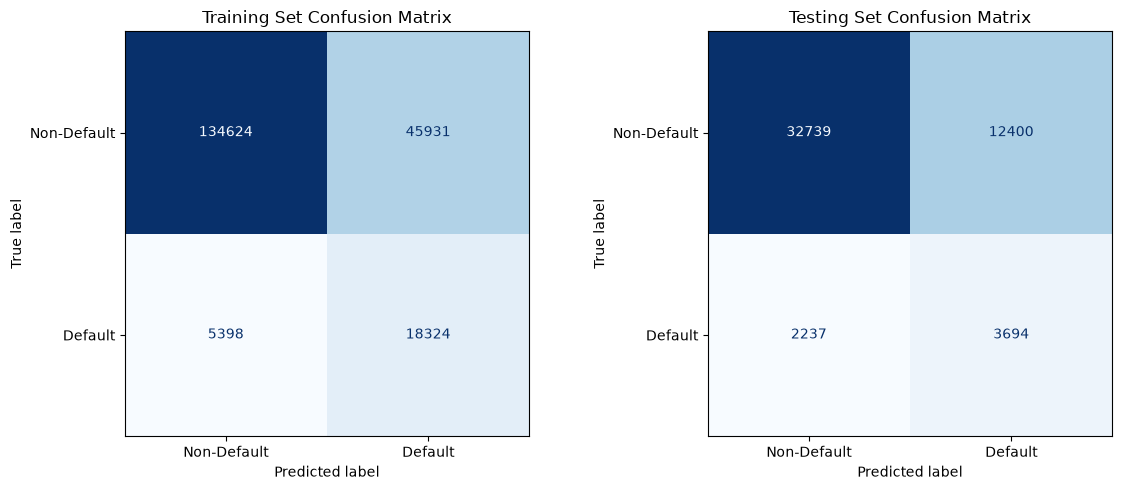

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_train_pred_xgb,
    display_labels=["Non-Default", "Default"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Training Set Confusion Matrix")

# Testing Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_xgb,
    display_labels=["Non-Default", "Default"],
    cmap="Blues",
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Testing Set Confusion Matrix")

plt.tight_layout()
plt.show()

### Interpretation

- The training confusion matrix shows that the baseline XGBoost model captures the majority of both classes, indicating strong learning on the training data.

- The testing confusion matrix is reasonably balanced, but the presence of a noticeable number of false positives and false negatives shows that the model still makes a fair number of misclassifications on unseen data.

- Overall, the confusion matrices suggest that XGBoost generalizes better than a highly overfit model, but there is still room for improvement through hyperparameter tuning.

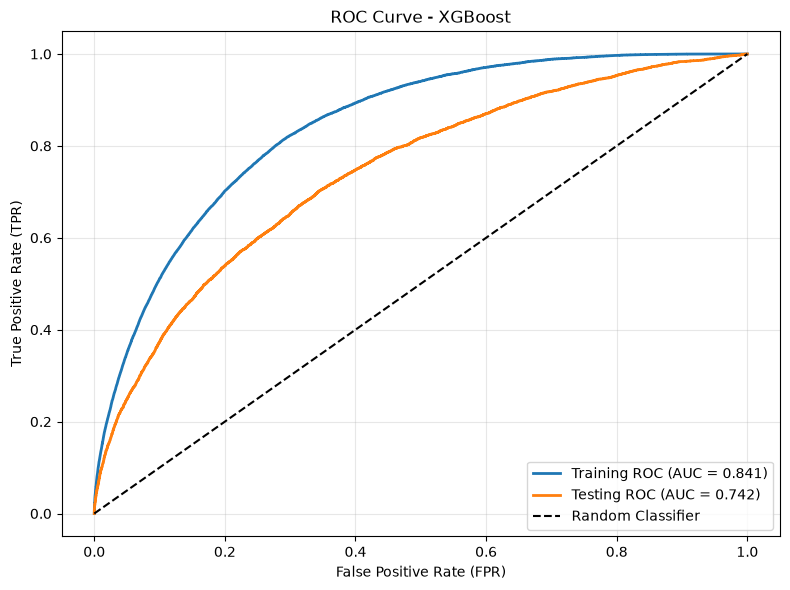

In [25]:
# ROC curve coordinates
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob_xgb)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob_xgb)

# ROC-AUC
train_auc = roc_auc_score(y_train, y_train_prob_xgb)
test_auc = roc_auc_score(y_test, y_test_prob_xgb)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_train,
    tpr_train,
    linewidth=2,
    label=f"Training ROC (AUC = {train_auc:.3f})"
)

plt.plot(
    fpr_test,
    tpr_test,
    linewidth=2,
    label=f"Testing ROC (AUC = {test_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - XGBoost")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

- The ROC curves for both the training and testing datasets lie well above the random classifier, indicating that the XGBoost model has good discriminative ability.

- The higher **training ROC-AUC (0.841)** compared with the **testing ROC-AUC (0.742)** suggests that the baseline model exhibits a moderate degree of overfitting, although it still generalizes reasonably well to unseen data.

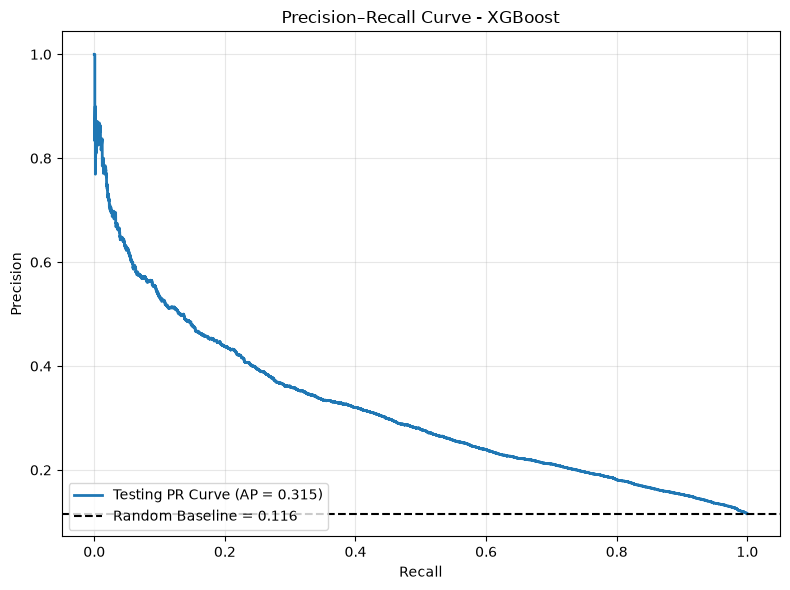

In [26]:
# Precision-Recall values
precision, recall, _ = precision_recall_curve(y_test, y_test_prob_xgb)

# Average Precision (AP)
ap = average_precision_score(y_test, y_test_prob_xgb)

# Baseline precision
baseline = y_test.mean()

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"Testing PR Curve (AP = {ap:.3f})"
)

plt.axhline(
    baseline,
    color="black",
    linestyle="--",
    label=f"Random Baseline = {baseline:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - XGBoost")

plt.grid(alpha=0.3)
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

### Interpretation

- The Precision–Recall curve lies well above the random baseline, indicating that the XGBoost model identifies default borrowers substantially better than random guessing.

- The **Average Precision (AP = 0.315)** demonstrates good overall performance across different classification thresholds, although Precision decreases as Recall increases, reflecting the trade-off between identifying more defaults and generating more false positives.

## Hyperparameter Tuning

The baseline XGBoost model uses default hyperparameter values, which may not provide the optimal balance between predictive performance and model complexity. Therefore, **hyperparameter tuning** is performed to identify the combination of parameters that maximizes the model's ability to generalize to unseen data.

In this study, **RandomizedSearchCV** with **5-fold Stratified Cross-Validation** is employed. Unlike Grid Search, which evaluates every possible hyperparameter combination, Randomized Search samples a fixed number of randomly selected combinations from the predefined search space. This approach is computationally more efficient for models such as XGBoost, where the number of hyperparameters is relatively large.

The objective is to maximize the **Area Under the Receiver Operating Characteristic Curve (ROC-AUC)**, since this metric evaluates the model's ability to distinguish between default and non-default borrowers across all possible classification thresholds.

The following hyperparameters are optimized:

- **n_estimators:** Number of boosting rounds (decision trees).
- **learning_rate:** Step size controlling the contribution of each new tree.
- **max_depth:** Maximum depth of each decision tree.
- **min_child_weight:** Minimum sum of observation weights required in a leaf node.
- **subsample:** Fraction of training observations randomly sampled for each tree.
- **colsample_bytree:** Fraction of predictor variables randomly sampled for constructing each tree.
- **gamma:** Minimum loss reduction required before creating an additional split.

The best hyperparameter combination obtained from cross-validation is selected as the **final tuned XGBoost model** and will subsequently be evaluated on the testing dataset.

In [27]:
#from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
#from xgboost import XGBClassifier

# Cross-validation strategy
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Hyperparameter search space
param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, 9],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5]
}

# Base XGBoost model
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    verbose=1,
    n_jobs=-1,
    return_train_score=True
)

# Perform hyperparameter tuning
random_search.fit(X_train, y_train)

# Best model
best_xgb = random_search.best_estimator_

print("=" * 60)
print("Best Hyperparameters")
print("=" * 60)
print(random_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:",
      f"{random_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Hyperparameters
{'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.9}

Best Cross-Validation ROC-AUC: 0.7533


### Interpretation

Hyperparameter tuning was completed using **RandomizedSearchCV** with **5-fold Stratified Cross-Validation**, evaluating **150 candidate models** using the **ROC-AUC** metric.

The optimal hyperparameter configuration obtained was:

- **Number of Trees (`n_estimators`) = 500**
- **Learning Rate (`learning_rate`) = 0.05**
- **Maximum Tree Depth (`max_depth`) = 3**
- **Minimum Child Weight (`min_child_weight`) = 1**
- **Subsample Ratio (`subsample`) = 0.9**
- **Column Sampling Ratio (`colsample_bytree`) = 0.9**
- **Minimum Loss Reduction (`gamma`) = 0.1**

The tuned model achieved a **mean cross-validation ROC-AUC of 0.7533**, indicating a slight improvement over the baseline model. These hyperparameter values represent the optimal balance between predictive performance and model complexity within the explored search space and are selected for constructing the final XGBoost classifier.

In [28]:
# ==============================
# Predictions using tuned XGBoost
# ==============================

y_train_pred_xgb_tuned = best_xgb.predict(X_train)
y_test_pred_xgb_tuned = best_xgb.predict(X_test)

y_train_prob_xgb_tuned = best_xgb.predict_proba(X_train)[:, 1]
y_test_prob_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]

# ==============================
# Tuned model performance
# ==============================

xgb_tuned_performance = pd.DataFrame({
    "Accuracy": [
        accuracy_score(y_train, y_train_pred_xgb_tuned),
        accuracy_score(y_test, y_test_pred_xgb_tuned)
    ],
    "Precision": [
        precision_score(y_train, y_train_pred_xgb_tuned),
        precision_score(y_test, y_test_pred_xgb_tuned)
    ],
    "Recall": [
        recall_score(y_train, y_train_pred_xgb_tuned),
        recall_score(y_test, y_test_pred_xgb_tuned)
    ],
    "F1-Score": [
        f1_score(y_train, y_train_pred_xgb_tuned),
        f1_score(y_test, y_test_pred_xgb_tuned)
    ],
    "ROC-AUC": [
        roc_auc_score(y_train, y_train_prob_xgb_tuned),
        roc_auc_score(y_test, y_test_prob_xgb_tuned)
    ]
},
index=["Training Set", "Testing Set"])

xgb_tuned_performance = xgb_tuned_performance.round(4)

# ==============================
# Baseline vs Tuned Comparison
# ==============================

baseline_xgb = xgb_performance.copy()
baseline_xgb["Model"] = "Baseline"

tuned_xgb = xgb_tuned_performance.copy()
tuned_xgb["Model"] = "Tuned"

baseline_xgb["Dataset"] = baseline_xgb.index
tuned_xgb["Dataset"] = tuned_xgb.index

xgb_comparison = pd.concat(
    [baseline_xgb, tuned_xgb],
    ignore_index=True
)

xgb_comparison = xgb_comparison[
    [
        "Model",
        "Dataset",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]

print("Baseline vs Tuned XGBoost Performance")
display(xgb_comparison)

Baseline vs Tuned XGBoost Performance


,Model,Dataset,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline,Training Set,0.7487,0.2852,0.7724,0.4166,0.8415
1,Baseline,Testing Set,0.7134,0.2295,0.6228,0.3354,0.7421
2,Tuned,Training Set,0.6956,0.2310,0.6958,0.3468,0.7667
3,Tuned,Testing Set,0.6913,0.2271,0.6896,0.3416,0.7592


### Interpretation

- Hyperparameter tuning successfully improved the generalization ability of the XGBoost model. Although the training performance decreased, the testing performance became more representative of the model's true predictive capability.

- The **testing ROC-AUC increased from 0.7421 to 0.7592**, indicating that the tuned model is better at distinguishing between default and non-default borrowers on unseen data.

- The reduction in the gap between the training and testing metrics suggests that the tuned model exhibits **less overfitting** than the baseline model.

- While Accuracy and Precision changed only marginally, the tuned model achieved a better overall balance between model complexity and predictive performance, making it a more reliable classifier for deployment.

- Therefore, the **tuned XGBoost model** is selected as the final XGBoost classifier for all subsequent analyses, including feature importance and comparison with the other machine learning models.

## Feature Importance

Unlike Logistic Regression, XGBoost does not estimate regression coefficients. Instead, it quantifies the importance of each predictor based on its contribution to reducing the model's objective function during the construction of the boosted decision trees.

The feature importance values reported by **XGBClassifier** represent the relative contribution of each predictor to the model's predictions. Features with higher importance values contribute more frequently and more effectively to improving the predictive performance of the model.

It is important to note that these importance values indicate **predictive contribution** rather than **causal influence**. Therefore, they should be interpreted as measures of a feature's usefulness for prediction and not as evidence of cause-and-effect relationships.

,Feature,Importance
0,Age,0.2345
1,InterestRate,0.1098
2,Income,0.0897
3,MonthsEmployed,0.0738
4,HasCoSigner,0.0558
5,LoanAmount,0.0545
6,HasDependents,0.0511
7,EmploymentType_Unemployed,0.0413
8,Education_High School,0.0334
9,LoanPurpose_Home,0.0310


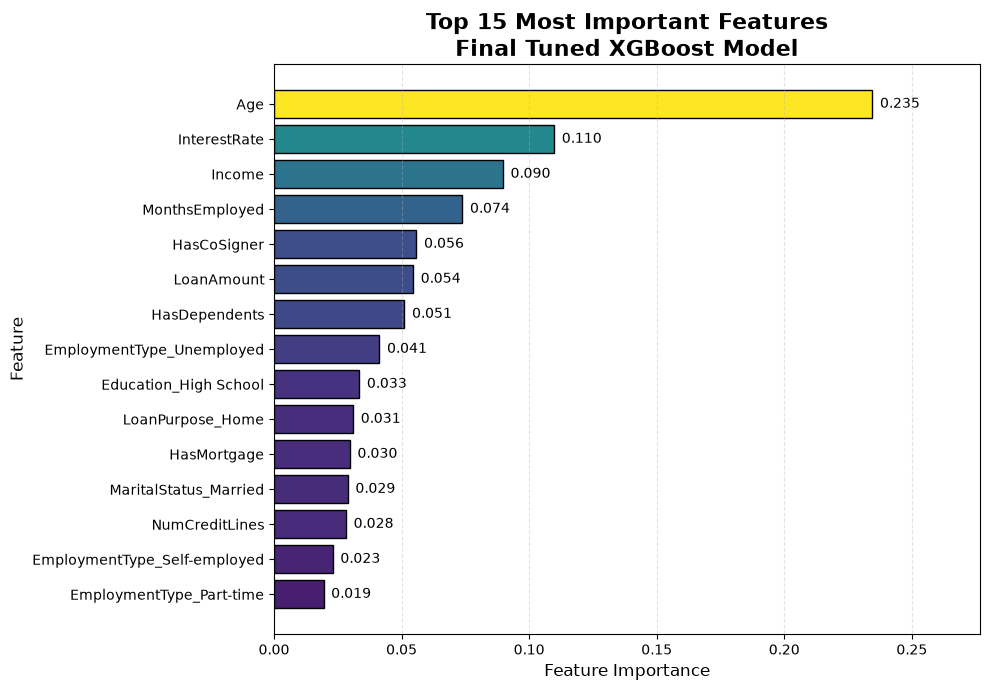

In [29]:
import matplotlib.pyplot as plt

# ==========================
# Feature Importance Table
# ==========================

feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df["Importance"] = feature_importance_df["Importance"].round(4)

display(feature_importance_df)

# ==========================
# Top 15 Feature Importance Plot
# ==========================

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1],
    color=plt.cm.viridis(
        top_features["Importance"][::-1] /
        top_features["Importance"].max()
    ),
    edgecolor="black"
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.003,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        fontsize=10
    )

plt.title(
    "Top 15 Most Important Features\nFinal Tuned XGBoost Model",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Feature Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)

plt.xlim(0, top_features["Importance"].max() * 1.18)

plt.grid(axis="x", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

# Model Comparison

Three machine learning algorithms—**Logistic Regression**, **Random Forest**, and **XGBoost**—were developed and individually optimized for predicting loan default.

To determine the most appropriate model, the **final tuned versions** of all three algorithms are compared using their performance on the **testing dataset**, which provides an unbiased estimate of how well each model generalizes to unseen observations.

The comparison is based on the following evaluation metrics:

- **Accuracy:** Overall proportion of correctly classified observations.
- **Precision:** Proportion of predicted defaults that are actual defaults.
- **Recall:** Proportion of actual defaults correctly identified.
- **F1-score:** Harmonic mean of Precision and Recall.
- **ROC-AUC:** Overall ability of the classifier to distinguish between default and non-default borrowers across all classification thresholds.

The objective of this comparison is to identify the model that provides the best balance between predictive performance, generalization ability, and suitability for loan default prediction.

In [30]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        tuned_performance.loc["Testing Set", "Accuracy"],
        rf_tuned_performance.loc["Testing Set", "Accuracy"],
        xgb_tuned_performance.loc["Testing Set", "Accuracy"]
    ],
    "Precision": [
        tuned_performance.loc["Testing Set", "Precision"],
        rf_tuned_performance.loc["Testing Set", "Precision"],
        xgb_tuned_performance.loc["Testing Set", "Precision"]
    ],
    "Recall": [
        tuned_performance.loc["Testing Set", "Recall"],
        rf_tuned_performance.loc["Testing Set", "Recall"],
        xgb_tuned_performance.loc["Testing Set", "Recall"]
    ],
    "F1-Score": [
        tuned_performance.loc["Testing Set", "F1-Score"],
        rf_tuned_performance.loc["Testing Set", "F1-Score"],
        xgb_tuned_performance.loc["Testing Set", "F1-Score"]
    ],
    "ROC-AUC": [
        tuned_performance.loc["Testing Set", "ROC-AUC"],
        rf_tuned_performance.loc["Testing Set", "ROC-AUC"],
        xgb_tuned_performance.loc["Testing Set", "ROC-AUC"]
    ]
})

comparison_df = comparison_df.round(4)

print("Comparison of Final Tuned Models (Testing Set)")
display(comparison_df)

Comparison of Final Tuned Models (Testing Set)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.6766,0.2198,0.7001,0.3346,0.7532
1,Random Forest,0.7852,0.2786,0.5343,0.3662,0.7542
2,XGBoost,0.6913,0.2271,0.6896,0.3416,0.7592


### Interpretation

- The three tuned models exhibit different performance characteristics, indicating that no single algorithm is superior across all evaluation metrics.

- **Random Forest** achieved the highest **Accuracy (0.7852)** and **F1-score (0.3662)**, suggesting the best overall balance between correctly identifying default and non-default borrowers.

- **Logistic Regression** obtained the highest **Recall (0.7001)**, making it the most effective model for identifying actual loan defaults, although this was achieved with relatively lower Precision.

- **XGBoost** achieved the highest **ROC-AUC (0.7592)**, indicating the strongest overall ability to discriminate between default and non-default borrowers across all possible classification thresholds.

- Since each model excels in different aspects, further comparison using graphical performance analysis is conducted before selecting the final model.

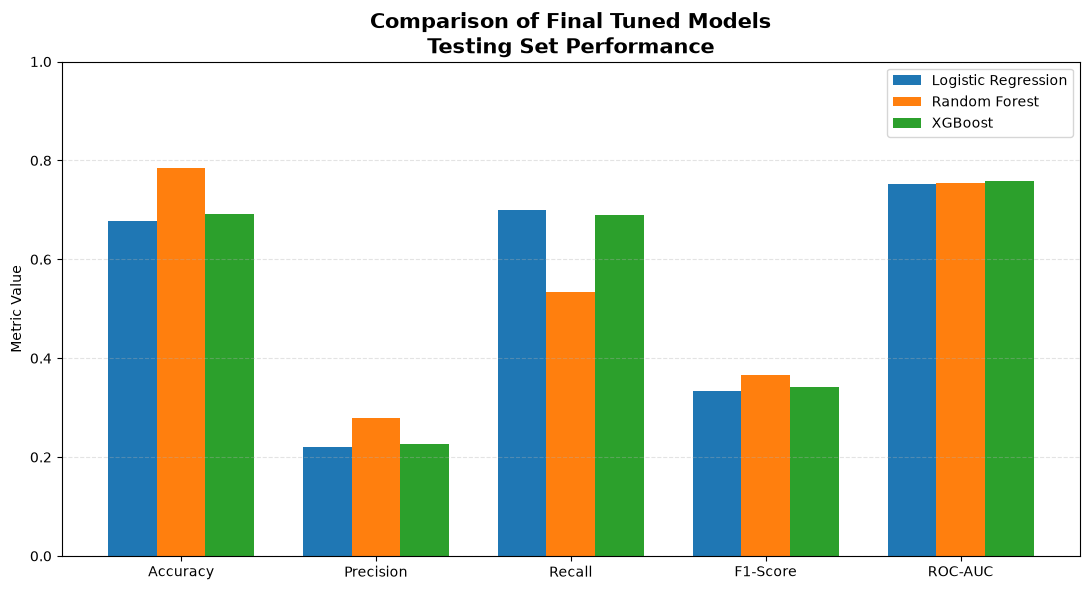

In [31]:
# Metrics to compare
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

# Use model names instead of row positions
comparison_plot = comparison_df.set_index("Model")

lr_values = comparison_plot.loc["Logistic Regression", metrics].values
rf_values = comparison_plot.loc["Random Forest", metrics].values
xgb_values = comparison_plot.loc["XGBoost", metrics].values

# Plot settings
x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(11, 6))

# Logistic Regression
plt.bar(
    x - width,
    lr_values,
    width,
    label="Logistic Regression"
)

# Random Forest
plt.bar(
    x,
    rf_values,
    width,
    label="Random Forest"
)

# XGBoost
plt.bar(
    x + width,
    xgb_values,
    width,
    label="XGBoost"
)

plt.xticks(x, metrics)
plt.ylabel("Metric Value")
plt.ylim(0, 1)

plt.title(
    "Comparison of Final Tuned Models\nTesting Set Performance",
    fontsize=15,
    weight="bold"
)

plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.legend()

plt.tight_layout()
plt.show()

### Interpretation

- The grouped bar chart highlights that each machine learning model exhibits distinct strengths, indicating that no single model is superior across all evaluation metrics.

- **Random Forest** achieved the highest **Accuracy**, **Precision**, and **F1-score**, demonstrating the strongest overall classification performance and the best balance between identifying default and non-default borrowers.

- **Logistic Regression** achieved the highest **Recall**, making it the most effective model for detecting actual loan defaults. However, this improvement came at the expense of lower Precision, resulting in more false positive predictions.

- **XGBoost** achieved the highest **ROC-AUC**, indicating the strongest overall discriminative ability across all possible classification thresholds and the best capacity to distinguish between default and non-default borrowers.

- Overall, the figure demonstrates that model selection depends on the evaluation objective. When balanced classification performance is prioritized, Random Forest performs best, whereas XGBoost provides the strongest ranking capability according to ROC-AUC. Logistic Regression remains a competitive and highly interpretable baseline model.

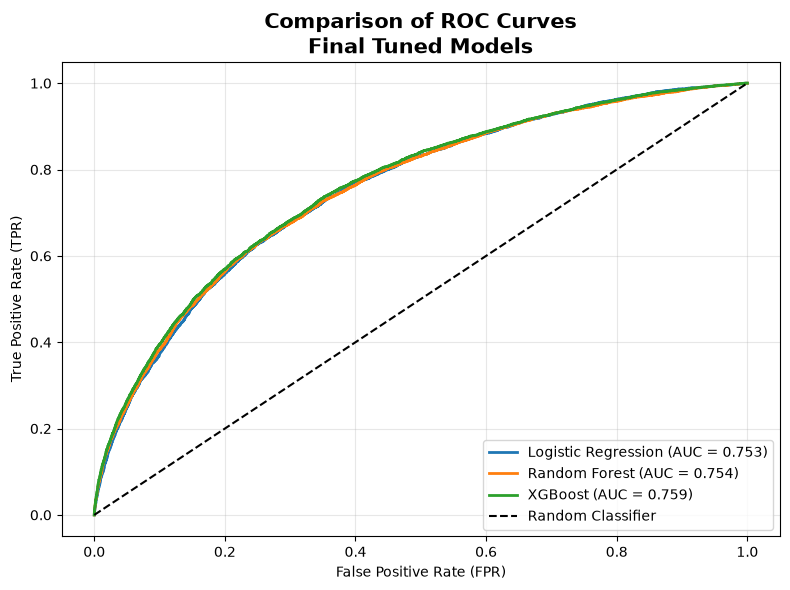

In [32]:
# ROC coordinates
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_prob_tuned)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_prob_rf_tuned)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_test_prob_xgb_tuned)

# ROC-AUC scores
auc_lr = roc_auc_score(y_test, y_test_prob_tuned)
auc_rf = roc_auc_score(y_test, y_test_prob_rf_tuned)
auc_xgb = roc_auc_score(y_test, y_test_prob_xgb_tuned)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc_lr:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    linewidth=2,
    label=f"XGBoost (AUC = {auc_xgb:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.title(
    "Comparison of ROC Curves\nFinal Tuned Models",
    fontsize=15,
    weight="bold"
)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")

plt.grid(alpha=0.3)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

### Interpretation

- The ROC curves of the three tuned models are closely clustered, indicating that all models exhibit comparable discriminative performance on the testing dataset.

- Although the curves largely overlap, **XGBoost** consistently remains slightly above the other models and achieves the highest **ROC-AUC (0.7592)**, indicating the strongest overall ability to distinguish between default and non-default borrowers.

- **Random Forest** performs similarly to XGBoost, while **Logistic Regression** achieves only a marginally lower ROC-AUC despite being the simplest and most interpretable model.

- The small differences between the ROC curves suggest that all three algorithms provide competitive predictive performance, and the final model selection should therefore consider not only ROC-AUC but also other evaluation metrics, interpretability, and model complexity.

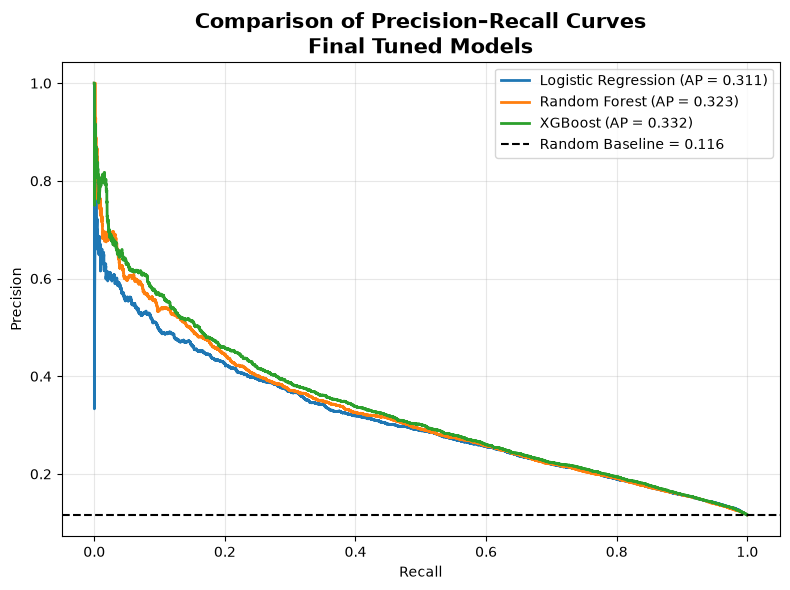

In [33]:
from sklearn.metrics import precision_recall_curve, average_precision_score

import matplotlib.pyplot as plt



# Precision-Recall coordinates

precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_test_prob_tuned)

precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_test_prob_rf_tuned)

precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_test_prob_xgb_tuned)



# Average Precision scores

ap_lr = average_precision_score(y_test, y_test_prob_tuned)

ap_rf = average_precision_score(y_test, y_test_prob_rf_tuned)

ap_xgb = average_precision_score(y_test, y_test_prob_xgb_tuned)



# Baseline precision (prevalence of the positive class)

baseline = y_test.mean()



plt.figure(figsize=(8, 6))



plt.plot(

    recall_lr,

    precision_lr,

    linewidth=2,

    label=f"Logistic Regression (AP = {ap_lr:.3f})"

)



plt.plot(

    recall_rf,

    precision_rf,

    linewidth=2,

    label=f"Random Forest (AP = {ap_rf:.3f})"

)



plt.plot(

    recall_xgb,

    precision_xgb,

    linewidth=2,

    label=f"XGBoost (AP = {ap_xgb:.3f})"

)



plt.axhline(

    y=baseline,

    color="black",

    linestyle="--",

    linewidth=1.5,

    label=f"Random Baseline = {baseline:.3f}"

)



plt.title(

    "Comparison of Precision–Recall Curves\nFinal Tuned Models",

    fontsize=15,

    weight="bold"

)



plt.xlabel("Recall")

plt.ylabel("Precision")



plt.grid(alpha=0.3)

plt.legend(loc="upper right")



plt.tight_layout()

plt.show()

### Interpretation

- The Precision–Recall curves of the three tuned models exhibit similar performance, indicating that all models are reasonably effective at identifying default borrowers despite the class imbalance.

- **XGBoost** achieved the highest **Average Precision (AP = 0.332)**, followed by **Random Forest (AP = 0.323)** and **Logistic Regression (AP = 0.311)**. This suggests that XGBoost maintains the best balance between Precision and Recall across different classification thresholds.

- All three models perform substantially better than the **random baseline (0.116)**, demonstrating that each classifier has learned meaningful patterns for distinguishing default from non-default borrowers.

- Although XGBoost consistently performs slightly better, the relatively small differences among the curves indicate that the three tuned models possess comparable predictive capability. Therefore, the final model selection should consider overall predictive performance together with interpretability, computational complexity, and practical deployment requirements.

In [34]:
model_selection = pd.DataFrame({

    "Criterion": [
        "Testing Accuracy",
        "Testing Precision",
        "Testing Recall",
        "Testing F1-Score",
        "Testing ROC-AUC",
        "Interpretability",
        "Training Speed",
        "Prediction Speed",
        "Overfitting Risk",
        "Feature Importance",
        "Recommended Use"
    ],

    "Logistic Regression": [
        f"{tuned_performance.loc['Testing Set','Accuracy']:.4f}",
        f"{tuned_performance.loc['Testing Set','Precision']:.4f}",
        f"{tuned_performance.loc['Testing Set','Recall']:.4f}",
        f"{tuned_performance.loc['Testing Set','F1-Score']:.4f}",
        f"{tuned_performance.loc['Testing Set','ROC-AUC']:.4f}",
        "High",
        "Fast",
        "Very Fast",
        "Low",
        "Coefficients & Odds Ratios",
        "Explainable baseline model"
    ],

    "Random Forest": [
        f"{rf_tuned_performance.loc['Testing Set','Accuracy']:.4f}",
        f"{rf_tuned_performance.loc['Testing Set','Precision']:.4f}",
        f"{rf_tuned_performance.loc['Testing Set','Recall']:.4f}",
        f"{rf_tuned_performance.loc['Testing Set','F1-Score']:.4f}",
        f"{rf_tuned_performance.loc['Testing Set','ROC-AUC']:.4f}",
        "Medium",
        "Moderate",
        "Fast",
        "Medium",
        "Impurity-based Importance",
        "Balanced predictive performance"
    ],

    "XGBoost": [
        f"{xgb_tuned_performance.loc['Testing Set','Accuracy']:.4f}",
        f"{xgb_tuned_performance.loc['Testing Set','Precision']:.4f}",
        f"{xgb_tuned_performance.loc['Testing Set','Recall']:.4f}",
        f"{xgb_tuned_performance.loc['Testing Set','F1-Score']:.4f}",
        f"{xgb_tuned_performance.loc['Testing Set','ROC-AUC']:.4f}",
        "Low",
        "Moderate",
        "Fast",
        "Low",
        "Gain-based Importance",
        "Best discriminative performance"
    ]

})

display(model_selection)

,Criterion,Logistic Regression,Random Forest,XGBoost
0,Testing Accuracy,0.6766,0.7852,0.6913
1,Testing Precision,0.2198,0.2786,0.2271
2,Testing Recall,0.7001,0.5343,0.6896
3,Testing F1-Score,0.3346,0.3662,0.3416
4,Testing ROC-AUC,0.7532,0.7542,0.7592
5,Interpretability,High,Medium,Low
6,Training Speed,Fast,Moderate,Moderate
7,Prediction Speed,Very Fast,Fast,Fast
8,Overfitting Risk,Low,Medium,Low
9,Feature Importance,Coefficients & Odds Ratios,Impurity-based Importance,Gain-based Importance


## Final Model Selection




The final tuned Logistic Regression, Random Forest, and XGBoost models were evaluated on an independent test dataset using several performance metrics. Because loan default prediction is an **imbalanced binary classification** problem, model selection should not be based solely on threshold-dependent measures such as Accuracy, Precision, Recall, and F1-score. These metrics depend on the chosen classification threshold (0.5 in this study) and may not fully reflect a model's overall predictive ability. Instead, greater importance is given to **ROC-AUC** and **Average Precision (AP)**, which evaluate model performance across all classification thresholds and provide a more reliable assessment for imbalanced datasets.

Overall, the three models performed competitively, with only small differences across the evaluation metrics.

**Logistic Regression** achieved the highest **Recall (0.7001)**, meaning it identified the greatest proportion of actual loan defaults. In addition to its predictive performance, it offers excellent interpretability through regression coefficients and odds ratios, making it the most transparent and easily explainable model among the three.

**Random Forest** produced the highest **Accuracy (0.7852)**, **Precision (0.2786)**, and **F1-score (0.3662)**. These results indicate strong classification performance at the selected decision threshold, with a good balance between correctly identifying default and non-default borrowers.

**XGBoost** achieved the highest **ROC-AUC (0.7592)** and **Average Precision (0.332)**, indicating the strongest overall ability to distinguish between default and non-default borrowers across all possible classification thresholds. Although its advantage over the other models is relatively small, it consistently provided the best overall ranking performance on the test dataset.

Taking all evaluation metrics into account, **the tuned XGBoost model was selected as the final model for this study**. This decision is based primarily on its superior ROC-AUC and Average Precision, as these metrics are more appropriate for evaluating imbalanced classification problems than threshold-dependent measures alone. While Random Forest achieved slightly higher Accuracy and F1-score, these metrics reflect performance at only a single classification threshold and therefore do not necessarily indicate better overall discrimination.

It is also worth noting that the differences in performance among the three models are relatively modest, suggesting that each algorithm captures the underlying patterns in the data effectively. The selection of XGBoost is therefore based on its consistently stronger overall predictive performance rather than a dramatic improvement over the competing models. At the same time, Logistic Regression remains an important benchmark because of its high interpretability, allowing the effects of individual predictors to be explained through regression coefficients and odds ratios. As a result, it provides valuable insights into the factors influencing loan default while complementing the predictive strengths of the more complex machine learning models.


# Project Limitations

Although the selected XGBoost model achieved the best overall predictive performance, several limitations should be acknowledged.

- The dataset is synthetic and may not fully represent the complexity of real-world loan portfolios.
- Model performance was evaluated using a single train-test split. Although hyperparameter tuning employed Stratified 5-Fold Cross-Validation, external validation on an independent dataset was not performed.
- Default probability was converted into class labels using the default decision threshold of 0.5. Different thresholds may be more appropriate depending on business objectives, such as maximizing recall or minimizing false positives.
- Feature importance identifies variables that contribute to prediction but should not be interpreted as evidence of causal relationships.
- The model was trained using historical borrower information and therefore cannot account for future economic conditions or changes in lending policies.